## Class Distribution

Loading dataset for visualization...

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=True)...


C:\Users\User\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1365
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [10:43<00:00, 15.52it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=True)...


C:\Users\User\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:58<00:00, 18.91it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=True)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [02:17<00:00, 19.01it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_5576\337349765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


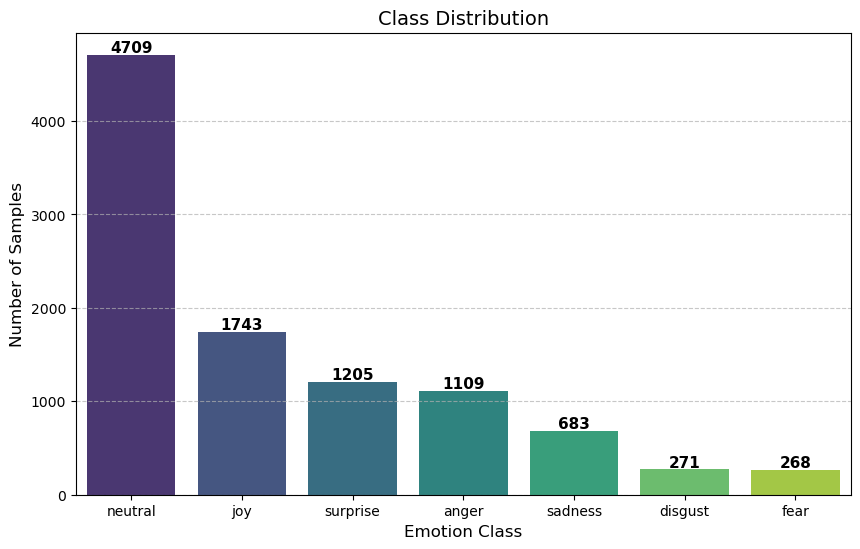

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from functions import prepare_datasets, Config

# 1. Load Data
print("Loading dataset for visualization...")
data = prepare_datasets(Config.DEFAULT_CLASSES)
y_train = data['y_train']
le = data['le_target']

# 2. Convert labels to names
class_names = le.inverse_transform(y_train)
df_dist = pd.DataFrame(class_names, columns=['Emotion'])

# 3. Plot
plt.figure(figsize=(10, 6))
# Professional color palette
palette = sns.color_palette("viridis", len(Config.DEFAULT_CLASSES))

ax = sns.countplot(
    x='Emotion', 
    data=df_dist, 
    order=df_dist['Emotion'].value_counts().index, 
    palette=palette
)

# 4. Add Count Labels on top of bars
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.title('Class Distribution', fontsize=14)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Sample Data

In [5]:
import pandas as pd
import librosa
from functions import Config
import os

df = pd.read_csv(Config.DATA_PATH + 'train_sent_emo.csv')

# Group by emotion and pick first sample
samples = df.groupby('Emotion').first().reset_index()

# Select columns for the table
# Note: 'Duration' needs to be calculated if not in CSV
print(f"{'Emotion':<10} | {'Sentiment':<10} | {'Duration':<10} | {'Dialogue'}")
print("-" * 80)

for _, row in samples.iterrows():
    # Calculate duration
    file_path = os.path.join(Config.DATA_PATH, row.get('Filepath', f"train/dia{row.get('Dialogue_ID')}_utt{row.get('Utterance_ID')}.wav"))
    try:
        y, sr = librosa.load(file_path, sr=16000)
        duration = f"{librosa.get_duration(y=y, sr=sr):.2f}s"
    except:
        duration = "N/A"
        
    print(f"{row['Emotion']:<10} | {row.get('Sentiment', 'N/A'):<10} | {duration:<10} | {row.get('Utterance', 'N/A')[:50]}...")

Emotion    | Sentiment  | Duration   | Dialogue
--------------------------------------------------------------------------------
anger      | negative   | N/A        | Oh no-no-no, give me some specifics....
disgust    | negative   | N/A        | Just coffee! Where are we gonna hang out now?...
fear       | negative   | N/A        | No dont I beg of you!...
joy        | positive   | N/A        | Do I ever....
neutral    | neutral    | N/A        | also I was the point person on my companys transi...
sadness    | negative   | N/A        | You know? Forget it!...
surprise   | positive   | N/A        | My duties?  All right....


C:\Users\User\AppData\Local\Temp\ipykernel_5576\3282788575.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=16000)
C:\Users\User\anaconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## Sample Data with Duration

In [9]:
import pandas as pd
import librosa
import os
from functions import Config

# FIX: Load the 'prepared' CSV which has the correct 'Filepath' column
csv_path = os.path.join(Config.DATA_PATH, 'prepared_train_sent_emo.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    # Define the specific order you want
    target_order = ['neutral', 'joy', 'anger', 'surprise', 'sadness', 'disgust', 'fear']
    
    print(f"{'Emotion':<10} | {'Sentiment':<10} | {'Duration':<10} | {'Dialogue'}")
    print("-" * 100)

    for emotion in target_order:
        # Get the first sample for this emotion
        row = df[df['Emotion'] == emotion].iloc[0]
        
        # Get path (Fixing the path issue)
        if os.path.exists(row['Filepath']):
            file_path = row['Filepath']
        else:
            file_path = os.path.join(Config.DATA_PATH, row['Filepath'])
            
        # Get Duration
        try:
            # sr=None reads the native sampling rate (faster)
            y, sr = librosa.load(file_path, sr=None) 
            duration = f"{librosa.get_duration(y=y, sr=sr):.2f}s"
        except Exception as e:
            duration = "Error"

        # Get Text (Truncate if too long)
        dialogue = row.get('Utterance', 'N/A')
        if len(dialogue) > 60:
            dialogue = dialogue[:57] + "..."
            
        print(f"{emotion:<10} | {row.get('Sentiment', 'N/A'):<10} | {duration:<10} | {dialogue}")

else:
    print("❌ Error: 'prepared_train_sent_emo.csv' not found. Please run data preparation first.")

Emotion    | Sentiment  | Duration   | Dialogue
----------------------------------------------------------------------------------------------------
neutral    | neutral    | 5.67s      | N/A
joy        | positive   | 1.83s      | N/A
anger      | negative   | 2.39s      | N/A
surprise   | positive   | 6.49s      | N/A
sadness    | negative   | 2.22s      | N/A
disgust    | negative   | 4.80s      | N/A
fear       | negative   | 2.01s      | N/A


## Audio Duration Distribution

Starting Analysis of Full MELD Dataset (Train + Dev + Test)...
--> Loading train split from: prepared_train_sent_emo.csv


Processing train: 100%|███████████████████████████████████████████████████████████| 9988/9988 [00:15<00:00, 639.17it/s]


--> Loading dev split from: prepared_dev_sent_emo.csv


Processing dev: 100%|██████████████████████████████████████████████████████████████| 1108/1108 [00:14<00:00, 79.07it/s]


--> Loading test split from: prepared_test_sent_emo.csv


Processing test: 100%|█████████████████████████████████████████████████████████████| 2610/2610 [00:33<00:00, 78.86it/s]


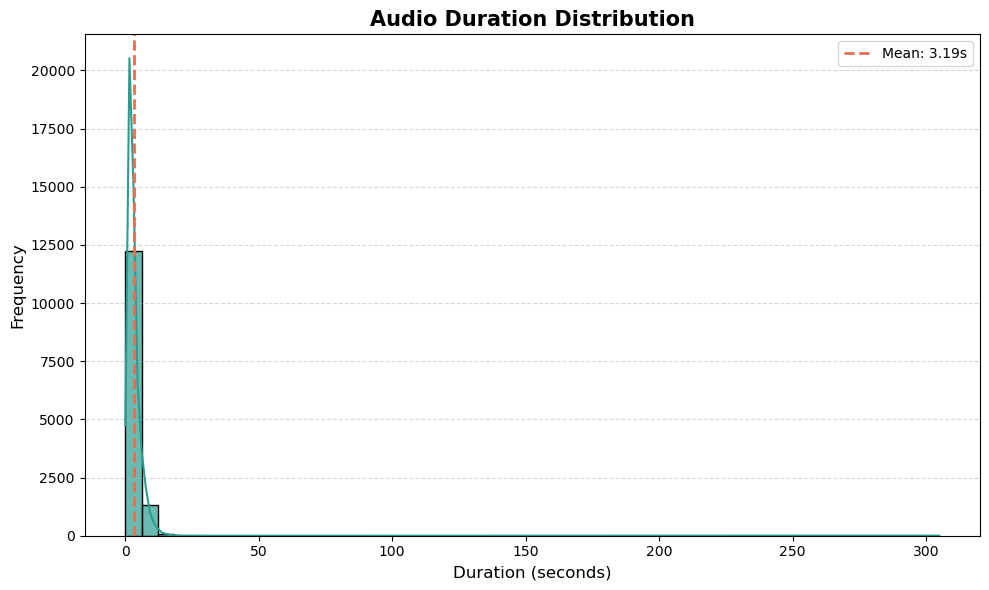


      FULL DATASET STATISTICS      
Total Samples Analyzed: 13706
Mean Duration:          3.19 s
Min Duration:           0.06 s
Max Duration:           304.96 s


In [3]:
import pandas as pd
import librosa
import os
import matplotlib.pyplot as plt
import seaborn as sns
from functions import Config
from tqdm import tqdm

# 1. Define Splits
splits = ['train', 'dev', 'test']
all_durations = []

print("Starting Analysis of Full MELD Dataset (Train + Dev + Test)...")

# 2. Iterate through each split
for split in splits:
    # Determine CSV path (checks for 'prepared' version first, else defaults to raw)
    csv_filename = f"{split}_sent_emo.csv"
    prepared_csv = f"prepared_{csv_filename}"
    
    if os.path.exists(os.path.join(Config.DATA_PATH, prepared_csv)):
        current_csv_path = os.path.join(Config.DATA_PATH, prepared_csv)
        print(f"--> Loading {split} split from: {prepared_csv}")
    else:
        current_csv_path = os.path.join(Config.DATA_PATH, csv_filename)
        print(f"--> Loading {split} split from: {csv_filename}")
        
    if not os.path.exists(current_csv_path):
        print(f"   [Warning] File not found: {current_csv_path}. Skipping...")
        continue

    df = pd.read_csv(current_csv_path)
    
    # Process audio files in this split
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split}"):
        try:
            # --- Logic to resolve file path ---
            f_path = None
            
            # Case A: Path is already in the CSV (Prepared version)
            if 'Filepath' in row:
                if os.path.exists(row['Filepath']):
                    f_path = row['Filepath']
                elif os.path.exists(os.path.join(Config.DATA_PATH, row['Filepath'])):
                    f_path = os.path.join(Config.DATA_PATH, row['Filepath'])
            
            # Case B: Construct path manually (Raw version)
            # Structure usually: DATA_PATH/train/diaX_uttY.wav
            if f_path is None:
                filename = f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.wav"
                # Assuming folders are named 'train', 'dev', 'test' inside DATA_PATH
                f_path = os.path.join(Config.DATA_PATH, split, filename)

            # --- Calculate Duration ---
            if f_path and os.path.exists(f_path):
                try:
                    # Fast check for Librosa >= 0.10
                    d = librosa.get_duration(path=f_path)
                except TypeError:
                    # Legacy Librosa
                    d = librosa.get_duration(filename=f_path)
                except Exception:
                    # Fallback method
                    y, sr = librosa.load(f_path, sr=None)
                    d = librosa.get_duration(y=y, sr=sr)
                
                all_durations.append(d)
        except Exception:
            continue

# 3. Plot Distribution (Combined)
if all_durations:
    plt.figure(figsize=(10, 6))
    sns.histplot(all_durations, kde=True, bins=50, color='#2a9d8f', edgecolor='black', alpha=0.7)

    # Calculate Global Mean
    mean_val = sum(all_durations) / len(all_durations)
    plt.axvline(mean_val, color='#e76f51', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}s')

    plt.title('Audio Duration Distribution', fontsize=15, fontweight='bold')
    plt.xlabel('Duration (seconds)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Print Summary Statistics
    print("\n" + "="*40)
    print("      FULL DATASET STATISTICS      ")
    print("="*40)
    print(f"Total Samples Analyzed: {len(all_durations)}")
    print(f"Mean Duration:          {mean_val:.2f} s")
    print(f"Min Duration:           {min(all_durations):.2f} s")
    print(f"Max Duration:           {max(all_durations):.2f} s")
    print("="*40)
else:
    print("Error: No audio files found. Check your Config.DATA_PATH.")

## Original vs. Augmented Audio Waveforms.

Selected Sample: dataset_meld/audio/wav_train/dia0_utt10.wav (Emotion: fear)


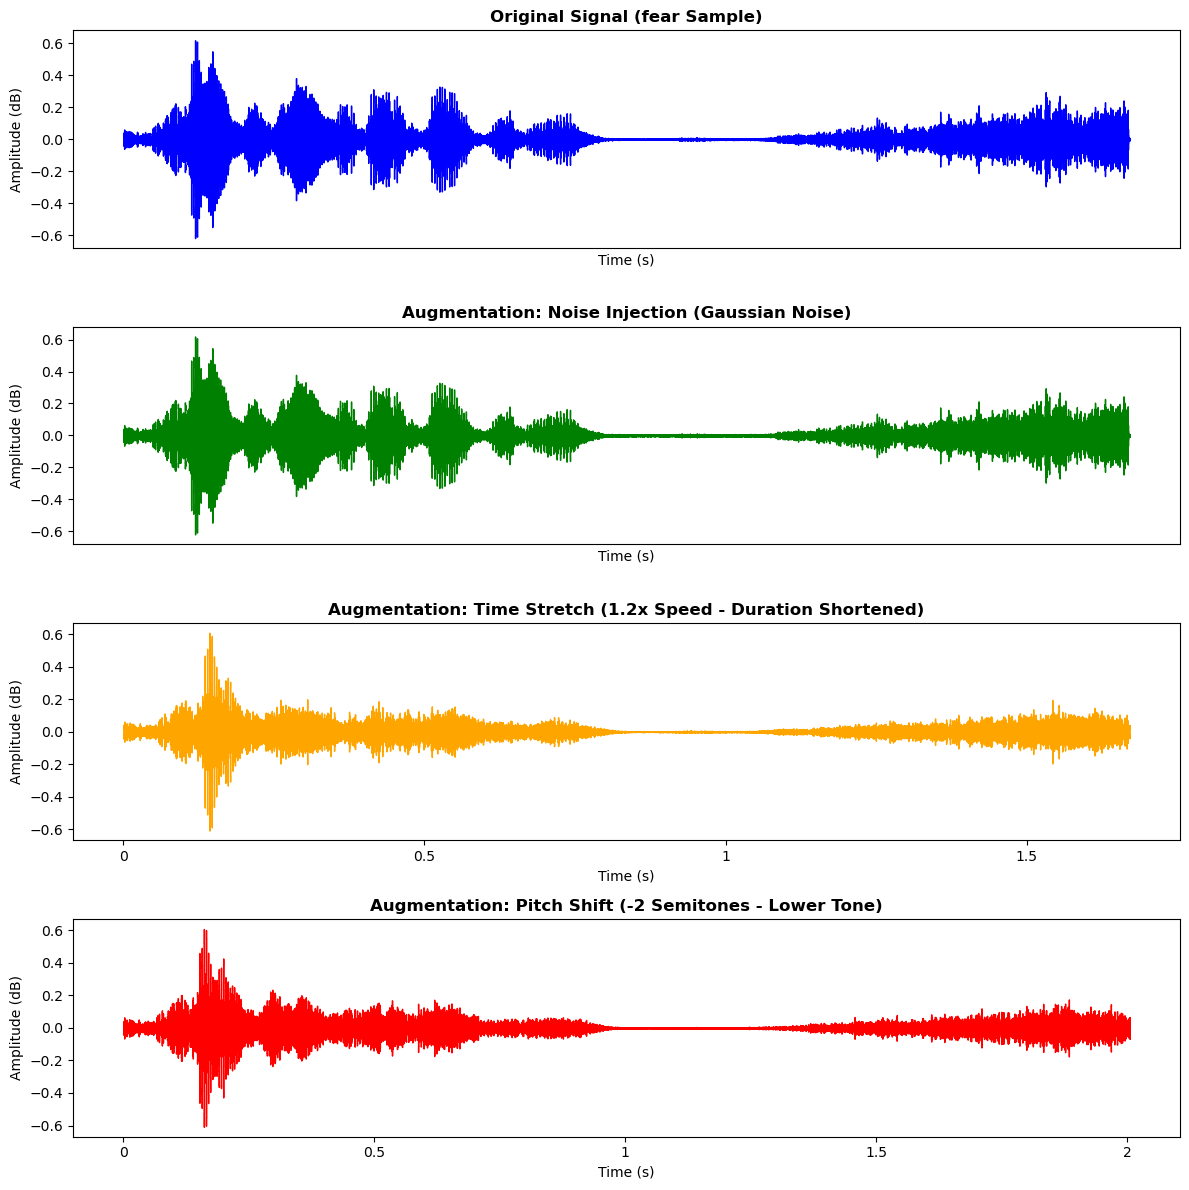

In [10]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from functions import Config # Assuming Config is in functions.py

# --- 1. Select a Sample from Minority Class (Fear) ---
csv_path = os.path.join(Config.DATA_PATH, 'prepared_train_sent_emo.csv')
df_prepare = pd.read_csv(csv_path)

# Filter for Fear
minority_samples = df_prepare[df_prepare['Emotion'].str.lower().isin(['fear'])]

if not minority_samples.empty:
    sample_row = minority_samples.iloc[0]
    if os.path.exists(sample_row['Filepath']):
        sample_file = sample_row['Filepath']
    else:
        sample_file = os.path.join(Config.DATA_PATH, sample_row['Filepath'])
    
    emotion_label = sample_row['Emotion']
    print(f"Selected Sample: {sample_file} (Emotion: {emotion_label})")
else:
    sample_file = os.path.join(Config.DATA_PATH, df_prepare.iloc[0]['Filepath'])
    emotion_label = df_prepare.iloc[0]['Emotion']
    print("⚠️ Minority class not found. Using first available file.")

# --- 2. Load Audio ---
y, sr = librosa.load(sample_file, sr=Config.SR)

# --- 3. Apply Augmentations ---
# A. Noise Injection
noise_amp = 0.005 * np.max(y)
y_noise = y + noise_amp * np.random.normal(size=len(y))

# B. Time Stretch (Faster = Shorter Duration)
y_stretch = librosa.effects.time_stretch(y, rate=1.2)

# C. Pitch Shift (Lower)
y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=-2)

# --- 4. Plot ---
plt.figure(figsize=(12, 12)) # Slightly taller to fit labels comfortably

# Plot 1: Original
plt.subplot(4, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title(f"Original Signal ({emotion_label} Sample)", fontsize=12, fontweight='bold')
plt.ylabel("Amplitude (dB)", fontsize=10)
plt.xlabel("Time (s)") # Hide X-label to reduce clutter
plt.xticks([]) # Hide X-ticks for cleaner look on top plots

# Plot 2: Noise Injection
plt.subplot(4, 1, 2)
librosa.display.waveshow(y_noise, sr=sr, color='green')
plt.title("Augmentation: Noise Injection (Gaussian Noise)", fontsize=12, fontweight='bold')
plt.ylabel("Amplitude (dB)", fontsize=10)
plt.xlabel("Time (s)") 
plt.xticks([])

# Plot 3: Time Stretch
plt.subplot(4, 1, 3)
librosa.display.waveshow(y_stretch, sr=sr, color='orange')
plt.title("Augmentation: Time Stretch (1.2x Speed - Duration Shortened)", fontsize=12, fontweight='bold')
plt.ylabel("Amplitude (dB)", fontsize=10)
plt.xlabel("Time (s)", fontsize=10) # Show X-label because the time scale changes here

# Plot 4: Pitch Shift
plt.subplot(4, 1, 4)
librosa.display.waveshow(y_pitch, sr=sr, color='red')
plt.title("Augmentation: Pitch Shift (-2 Semitones - Lower Tone)", fontsize=12, fontweight='bold')
plt.ylabel("Amplitude (dB)", fontsize=10)
plt.xlabel("Time (s)", fontsize=10) # Standard bottom X-label

plt.tight_layout()
plt.show()

## Data Augmentation on Model Performance

In [7]:
from functions import prepare_datasets, slice_features, build_dynamic_model, Config
from sklearn.utils import class_weight
import tensorflow as tf
import tf_keras
from sklearn.metrics import recall_score, accuracy_score, f1_score
import numpy as np
import pandas as pd
import gc

def run_augmentation_experiment():
    results = {}
    
    # Run twice: With and Without Augmentation
    for use_aug in [False, True]:
        print(f"\n--- Running Experiment: Augmentation = {use_aug} ---")
        
        # 1. Clean Memory to ensure fair independent runs
        tf.keras.backend.clear_session()
        gc.collect()
        
        # 2. Load Data (Using the explicit 'augment' parameter)
        # Note: We use the default 7 classes for this test to match Table 5.2
        data = prepare_datasets(Config.DEFAULT_CLASSES, augment=use_aug)
        
        # 3. Features (Standard set for fair comparison)
        feats = ['MFCC', 'Chroma', 'Sentiment']
        inputs, shapes, types = slice_features(data, feats)
        
        # 4. Train
        print("  Training model...")
        model = build_dynamic_model(types, shapes, len(Config.DEFAULT_CLASSES), data['num_sent_classes'])
        
        # Compute weights to handle imbalance (even with augmentation, this helps stability)
        cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
        
        # Short training run (15 epochs) is enough to see the *impact* of augmentation vs no augmentation
        model.fit(
            inputs['train'], data['y_train'], 
            epochs=15, 
            verbose=0, # Silent training to keep output clean
            batch_size=32, 
            class_weight=dict(enumerate(cw))
        )
        
        # 5. Metrics
        print("  Evaluating...")
        y_pred = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
        y_true = data['y_test']
        
        # Dynamic Index Lookup (Find where 'fear' and 'disgust' actually are)
        # This prevents bugs if class order changes (e.g. alphabetical sorting)
        classes = data['le_target'].classes_
        
        # specific check to ensure classes exist before accessing
        if 'fear' in classes and 'disgust' in classes:
            fear_idx = np.where(classes == 'fear')[0][0]
            disgust_idx = np.where(classes == 'disgust')[0][0]
            
            recalls = recall_score(y_true, y_pred, average=None)
            
            res = {
                'Overall Accuracy': accuracy_score(y_true, y_pred),
                'Macro F1-Score': f1_score(y_true, y_pred, average='macro'),
                'Fear Recall': recalls[fear_idx],
                'Disgust Recall': recalls[disgust_idx]
            }
            results[f'Aug_{use_aug}'] = res
        else:
            print("⚠️ Warning: 'fear' or 'disgust' not found in class list. Skipping specific recall metrics.")

    # 6. Final Output & Formatting
    print("\n--- Final Experiment Results (Table 5.2) ---")
    df_res = pd.DataFrame(results)
    
    # Calculate difference column automatically for your report
    df_res['Improvement'] = df_res['Aug_True'] - df_res['Aug_False']
    
    # Format for readability
    pd.options.display.float_format = '{:,.4f}'.format
    print(df_res)
    return df_res

# Run the experiment
df_results = run_augmentation_experiment()


--- Running Experiment: Augmentation = False ---


--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [05:52<00:00, 28.30it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:42<00:00, 25.84it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


...

Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=True)...


C:\Users\User\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [01:10<00:00, 15.66it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=True)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [02:53<00:00, 15.07it/s]


  Training model...
  Evaluating...

--- Final Experiment Results (Table 5.2) ---
                  Aug_False  Aug_True  Improvement
Overall Accuracy     0.6931    0.6847      -0.0084
Macro F1-Score       0.3938    0.3673      -0.0266
Fear Recall          0.4200    0.3400      -0.0800
Disgust Recall       0.2059    0.4265       0.2206


## Model Performance: With vs. Without Signal Pre-processing

In [7]:
from functions import prepare_datasets, slice_features, build_dynamic_model, Config
from sklearn.utils import class_weight
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, recall_score
import numpy as np
import pandas as pd
import gc

def run_preprocessing_ablation():
    # Define the 4 Experiments
    # Format: (Name, Do_Noise_Reduction, Do_Silence_Removal)
    experiments = [
        ("I (Raw)",   False, False),
        ("II (NR)",   True,  False),
        ("III (SR)",  False, True),
        ("IV (Both)", True,  True)
    ]
    
    results = []

    print(f"{'Exp':<10} | {'NR':<5} | {'SR':<5} | {'Status'}")
    print("-" * 40)

    for exp_name, do_nr, do_sr in experiments:
        print(f"{exp_name:<10} | {str(do_nr):<5} | {str(do_sr):<5} | Running...")
        
        # 1. Clear Memory & Session
        tf.keras.backend.clear_session()
        gc.collect()
        
        # 2. Load Data with specific flags
        # Note: We turn Augmentation OFF to isolate the effect of preprocessing
        data = prepare_datasets(Config.DEFAULT_CLASSES, 
                                clean_noise=do_nr, 
                                trim_silence=do_sr, 
                                augment=False)
        
        # 3. Features (Standard Set)
        feats = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
        inputs, shapes, types = slice_features(data, feats)
        
        # 4. Train
        model = build_dynamic_model(types, shapes, len(Config.DEFAULT_CLASSES), data['num_sent_classes'])
        cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
        
        model.fit(inputs['train'], data['y_train'], 
                  epochs=12, verbose=0, batch_size=32, 
                  class_weight=dict(enumerate(cw)))
        
        # 5. Metrics
        y_pred = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
        y_true = data['y_test']
        
        res_row = {
            'Experiment': exp_name,
            'Noise Reduction': 'Yes' if do_nr else 'No',
            'Silence Removal': 'Yes' if do_sr else 'No',
            'Accuracy': f"{accuracy_score(y_true, y_pred):.4f}",
            'Recall (Macro)': f"{recall_score(y_true, y_pred, average='macro'):.4f}",
            'F1-Score': f"{f1_score(y_true, y_pred, average='macro'):.4f}"
        }
        results.append(res_row)

    # 6. Output Final Table
    print("\n--- Final Results for Table 5.2 ---")
    df_results = pd.DataFrame(results)
    print(df_results)
    return df_results

# Run the experiment
df_ablation = run_preprocessing_ablation()

Exp        | NR    | SR    | Status
----------------------------------------
I (Raw)    | False | False | Running...

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [06:26<00:00, 25.83it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:49<00:00, 22.45it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


...

Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:37<00:00, 29.45it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:45<00:00, 24.67it/s]



--- Final Results for Table 5.2 ---
  Experiment Noise Reduction Silence Removal Accuracy Recall (Macro) F1-Score
0    I (Raw)              No              No   0.7107         0.4434   0.4227
1    II (NR)             Yes              No   0.6985         0.4460   0.3964
2   III (SR)              No             Yes   0.7261         0.4599   0.4173
3  IV (Both)             Yes             Yes   0.7115         0.4338   0.4115


## Linear Correlation Analysis.


--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [05:55<00:00, 28.07it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:30<00:00, 36.53it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:15<00:00, 34.75it/s]


Calculating correlations for 7 pairs...


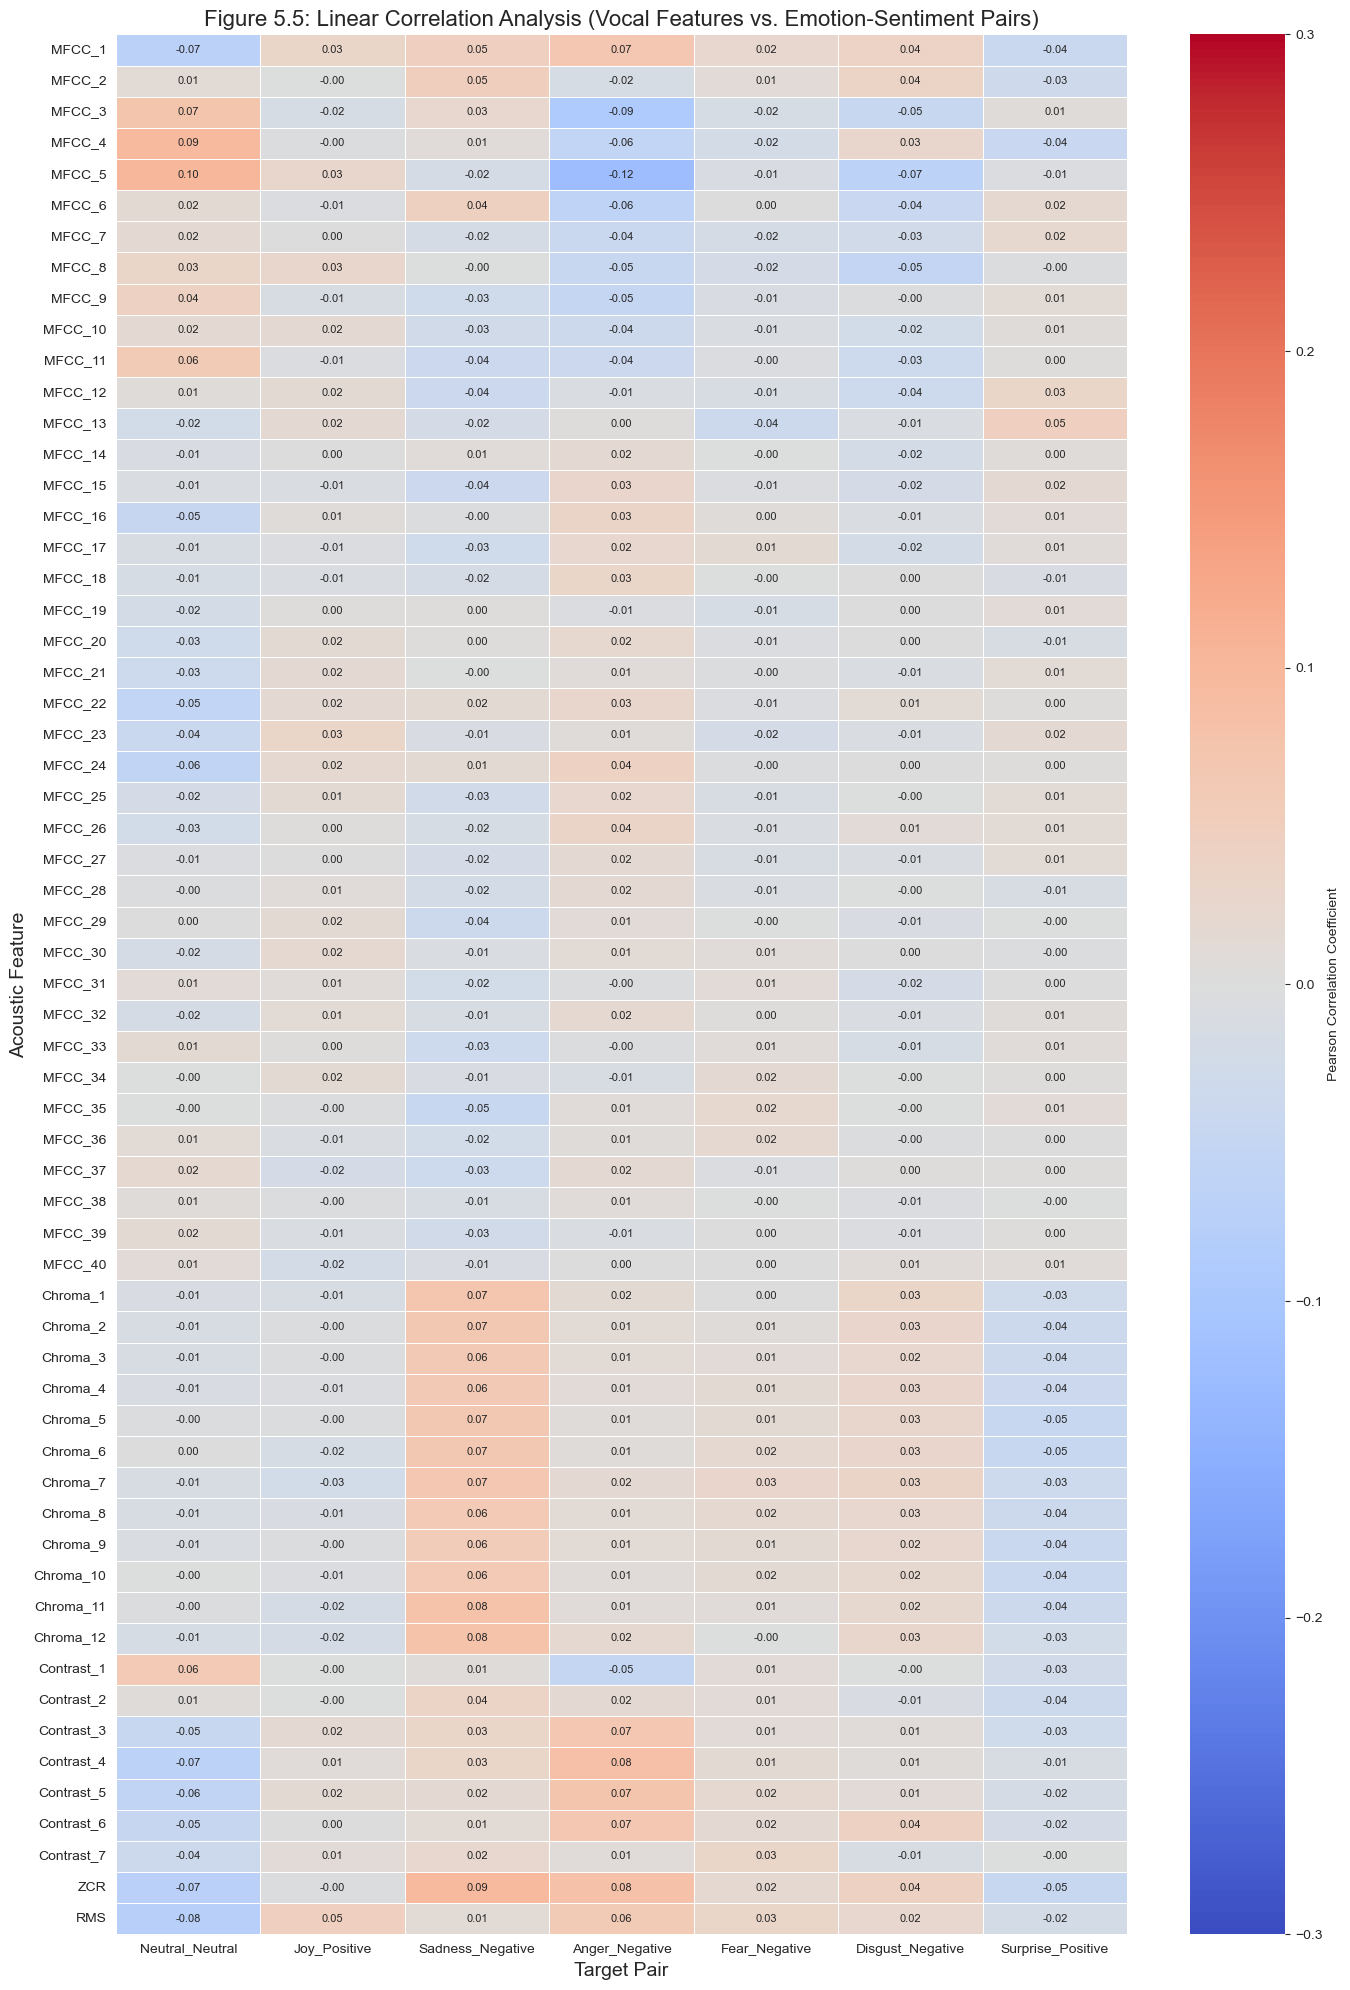

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from functions import prepare_datasets, Config

# 1. GET DATA
# Load the processed features and labels
data = prepare_datasets(Config.DEFAULT_CLASSES, augment=False)
X_mfcc = data['X_m_train']
X_stats = data['X_s_train']

# Load the original CSV to get string labels for Emotion and Sentiment
df_raw = pd.read_csv(Config.DATA_PATH + 'prepared_train_sent_emo.csv')

# 2. CONSTRUCT meld_df
# Flatten MFCCs (Take Mean across time steps)
mfcc_mean = np.mean(X_mfcc, axis=1)

# Create Feature Columns
mfcc_cols = [f'MFCC_{i+1}' for i in range(mfcc_mean.shape[1])]
chroma_cols = [f'Chroma_{i+1}' for i in range(12)]
contrast_cols = [f'Contrast_{i+1}' for i in range(7)]
stats_cols = chroma_cols + contrast_cols + ['ZCR', 'RMS']

# Combine into one DataFrame
features_array = np.hstack([mfcc_mean, X_stats])
all_feature_names = mfcc_cols + stats_cols

meld_df = pd.DataFrame(features_array, columns=all_feature_names)

# Add Target Columns
meld_df['Emotion'] = df_raw['Emotion']
meld_df['Sentiment'] = df_raw['Sentiment']

# 3. DEFINE PAIRS TO VISUALIZE
pairs_to_visualize = [
    ('neutral', 'neutral'),
    ('joy', 'positive'),
    ('sadness', 'negative'),
    ('anger', 'negative'),
    ('fear', 'negative'),
    ('disgust', 'negative'),
    ('surprise', 'positive')
]

# 4. CORRELATION LOOP
numeric_df = meld_df.select_dtypes(include=[np.number])
feature_cols = [c for c in numeric_df.columns if c in all_feature_names]

correlation_results = {}
print(f"Calculating correlations for {len(pairs_to_visualize)} pairs...")

for target_emotion, target_sentiment in pairs_to_visualize:
    col_name = f"{target_emotion.capitalize()}_{target_sentiment.capitalize()}"
    
    # Create Binary Target (1 = Match, 0 = No Match)
    binary_target = (
        (meld_df['Emotion'].str.lower() == target_emotion) & 
        (meld_df['Sentiment'].str.lower() == target_sentiment)
    ).astype(int)
    
    # Calculate Correlation
    correlations = meld_df[feature_cols].corrwith(binary_target)
    correlation_results[col_name] = correlations

# 5. CONVERT & PLOT
corr_table = pd.DataFrame(correlation_results)

# Plotting
# Increased figure height slightly to accommodate all 60+ rows comfortably
plt.figure(figsize=(14, 20)) 

sns.heatmap(corr_table, 
            annot=True,        # Show the numbers
            fmt=".2f",         # Format to 2 decimal places
            cmap='coolwarm', 
            vmin=-0.3, vmax=0.3, 
            center=0,
            linewidths=0.5,    # Add grid lines for clarity
            annot_kws={"size": 8}, # Reduce font size to prevent overlap
            cbar_kws={'label': 'Pearson Correlation Coefficient'})      

plt.title("Figure 5.6: Linear Correlation Analysis (Vocal Features vs. Emotion-Sentiment Pairs)", fontsize=16)
plt.xlabel("Target Pair", fontsize=14)
plt.ylabel("Acoustic Feature", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import os
from functions import prepare_datasets, Config

# 1. GET DATA
data = prepare_datasets(Config.DEFAULT_CLASSES, augment=False)
X_mfcc = data['X_m_train'] # (N, 94, 40)
X_stats = data['X_s_train'] # (N, 21)
df_raw = pd.read_csv(os.path.join(Config.DATA_PATH, 'prepared_train_sent_emo.csv'))

# 2. CONSTRUCT FEATURE DATAFRAME
# Flatten MFCCs (Mean across time) -> (N, 40)
mfcc_mean = np.mean(X_mfcc, axis=1)

# Define Column Names
mfcc_cols = [f'MFCC_{i+1}' for i in range(mfcc_mean.shape[1])]
chroma_cols = [f'Chroma_{i+1}' for i in range(12)]
contrast_cols = [f'Contrast_{i+1}' for i in range(7)]
stats_cols = chroma_cols + contrast_cols + ['ZCR', 'RMS']

# Combine
features_array = np.hstack([mfcc_mean, X_stats])
all_feature_names = mfcc_cols + stats_cols
meld_df = pd.DataFrame(features_array, columns=all_feature_names)

# Add Targets
meld_df['Emotion'] = df_raw['Emotion']
meld_df['Sentiment'] = df_raw['Sentiment']

# 3. DEFINE PAIRS
pairs_to_visualize = [
    ('neutral', 'neutral'),
    ('joy', 'positive'),
    ('sadness', 'negative'),
    ('anger', 'negative'),
    ('fear', 'negative'),
    ('disgust', 'negative'),
    ('surprise', 'positive')
]

# 4. CALCULATE CORRELATIONS
feature_cols = all_feature_names
correlation_results = {}

print("Calculating correlations...")

for target_emotion, target_sentiment in pairs_to_visualize:
    col_name = f"{target_emotion}_{target_sentiment}"
    
    # Binary Target: 1 if matches pair, 0 otherwise
    binary_target = (
        (meld_df['Emotion'].str.lower() == target_emotion) & 
        (meld_df['Sentiment'].str.lower() == target_sentiment)
    ).astype(int)
    
    # Point-Biserial Correlation
    correlations = meld_df[feature_cols].corrwith(binary_target)
    correlation_results[col_name] = correlations

# 5. PRINT EXACT NUMBERS
corr_table = pd.DataFrame(correlation_results)

# Formatting for easy reading/copying
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*50)
print(">>> COPY THE NUMBERS BELOW <<<")
print("="*50)
print(corr_table)
print("="*50)


--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [06:12<00:00, 26.85it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:30<00:00, 36.07it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:11<00:00, 36.59it/s]


Calculating correlations...

>>> COPY THE NUMBERS BELOW <<<
            neutral_neutral  joy_positive  sadness_negative  anger_negative  fear_negative  disgust_negative  surprise_positive
MFCC_1              -0.0681        0.0309            0.0470          0.0681         0.0245            0.0396            -0.0408
MFCC_2               0.0137       -0.0021            0.0498         -0.0156         0.0104            0.0361            -0.0316
MFCC_3               0.0728       -0.0151            0.0256         -0.0904        -0.0162           -0.0460             0.0070
MFCC_4               0.0949       -0.0043            0.0076         -0.0556        -0.0219            0.0260            -0.0443
MFCC_5               0.1030        0.0278           -0.0181         -0.1240        -0.0111           -0.0665            -0.0064
MFCC_6               0.0160       -0.0069            0.0446         -0.0613         0.0003           -0.0445             0.0188
MFCC_7               0.0184        0.0017   

## Emotion and Sentiment Distribution.

C:\Users\User\AppData\Local\Temp\ipykernel_5576\1821747328.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='Emotion', data=df, order=order, palette='viridis')


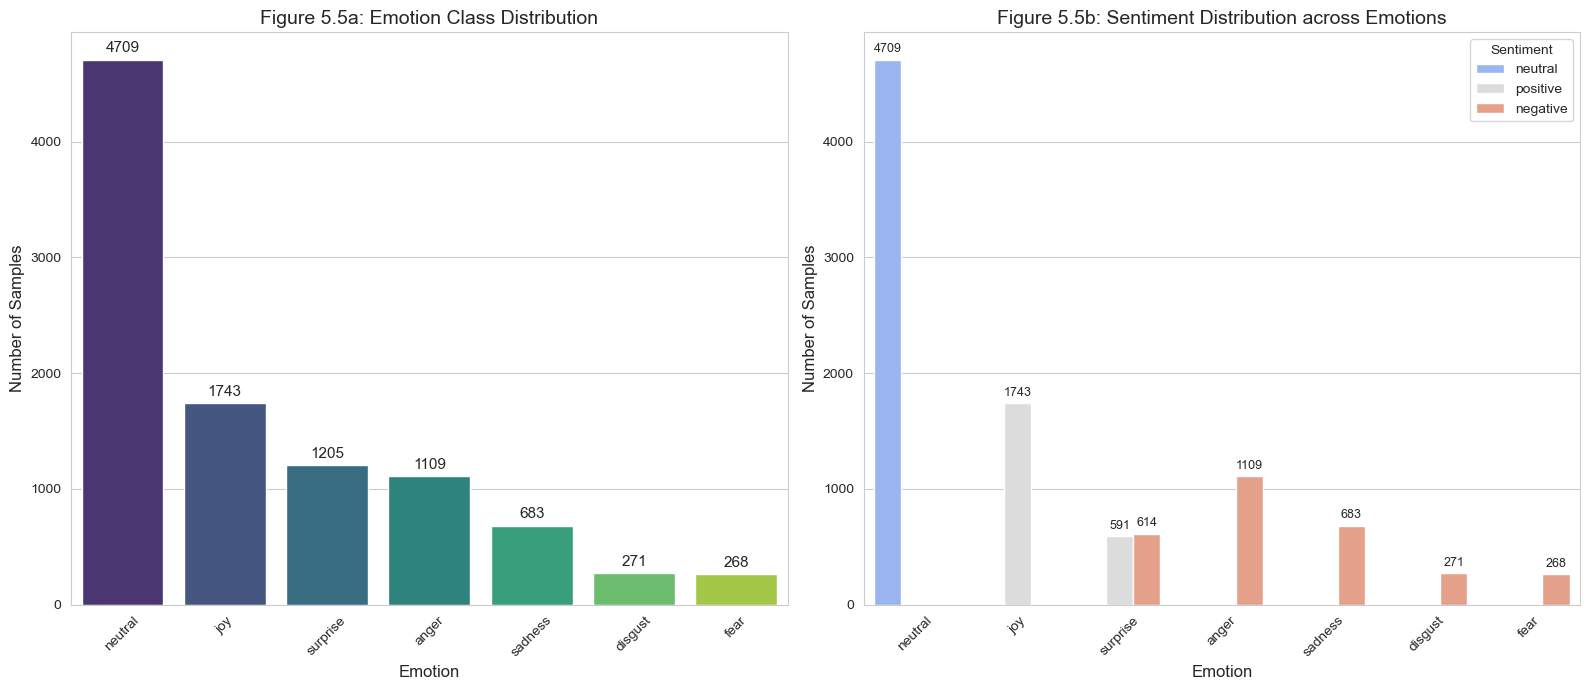


--- Distribution Summary ---
Sentiment  negative  neutral  positive  Total
Emotion                                      
neutral           0     4709         0   4709
joy               0        0      1743   1743
surprise        614        0       591   1205
anger          1109        0         0   1109
sadness         683        0         0    683
disgust         271        0         0    271
fear            268        0         0    268


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functions import Config

# 1. Load Data
csv_path = os.path.join(Config.DATA_PATH, 'prepared_train_sent_emo.csv')
if not os.path.exists(csv_path):
    print(f"❌ Error: {csv_path} not found. Please check your data path.")
else:
    df = pd.read_csv(csv_path)

    # Set up the figure
    plt.figure(figsize=(16, 7))
    sns.set_style("whitegrid")

    # --- Subplot 1: Emotion Class Distribution ---
    plt.subplot(1, 2, 1)
    # Order by count (descending) or fixed logical order
    order = ['neutral', 'joy', 'surprise', 'anger', 'sadness', 'disgust', 'fear']
    # Filter to ensure we only use classes that exist in the data
    order = [x for x in order if x in df['Emotion'].unique()]
    
    ax1 = sns.countplot(x='Emotion', data=df, order=order, palette='viridis')
    plt.title('Figure 5.5a: Emotion Class Distribution', fontsize=14)
    plt.xlabel('Emotion', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45)
    
    # Add value labels
    for container in ax1.containers:
        ax1.bar_label(container, fontsize=11, padding=3)

    # --- Subplot 2: Sentiment Distribution per Emotion ---
    plt.subplot(1, 2, 2)
    # We use 'hue' to show sentiment breakdown
    ax2 = sns.countplot(x='Emotion', hue='Sentiment', data=df, order=order, palette='coolwarm')
    
    plt.title('Figure 5.5b: Sentiment Distribution across Emotions', fontsize=14)
    plt.xlabel('Emotion', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment', loc='upper right')
    
    # Add value labels (might be crowded, so we use smaller font)
    for container in ax2.containers:
        ax2.bar_label(container, fontsize=9, padding=3)

    plt.tight_layout()
    plt.show()

    # Print Summary Table for checking
    print("\n--- Distribution Summary ---")
    summary = df.groupby(['Emotion', 'Sentiment']).size().unstack(fill_value=0)
    summary['Total'] = summary.sum(axis=1)
    print(summary.sort_values('Total', ascending=False))

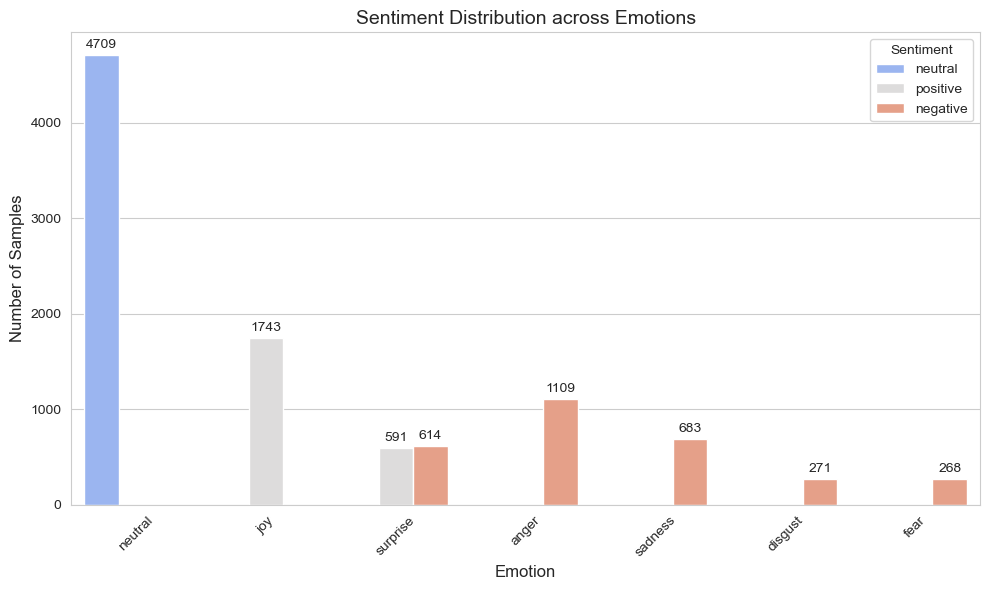

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functions import Config

# 1. Load Data
csv_path = os.path.join(Config.DATA_PATH, 'prepared_train_sent_emo.csv')

if not os.path.exists(csv_path):
    print(f"❌ Error: {csv_path} not found. Please check your data path.")
else:
    df = pd.read_csv(csv_path)

    # Set up the figure (Adjusted size for a single plot)
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Order by logical flow or count
    order = ['neutral', 'joy', 'surprise', 'anger', 'sadness', 'disgust', 'fear']
    order = [x for x in order if x in df['Emotion'].unique()]

    # --- Generate ONLY Figure 5.5b (Sentiment Distribution) ---
    ax = sns.countplot(x='Emotion', hue='Sentiment', data=df, order=order, palette='coolwarm')
    
    plt.title('Sentiment Distribution across Emotions', fontsize=14)
    plt.xlabel('Emotion', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment', loc='upper right')
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

    plt.tight_layout()
    plt.show()

## Feature Importance Ablation Study

Loading Dataset...

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [06:29<00:00, 25.66it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:28<00:00, 38.46it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:09<00:00, 37.31it/s]



--- Running Baseline (All Features) ---
Baseline Accuracy: 0.7115

--- Phase 2: Feature Sufficiency (Single Feature) ---
Testing ONLY MFCC...
   -> Acc: 0.0192
Testing ONLY Chroma...
   -> Acc: 0.1157
Testing ONLY Spectral_Contrast...
   -> Acc: 0.1257
Testing ONLY Zero_Crossing_Rate...
   -> Acc: 0.0927
Testing ONLY RMS_Energy...
   -> Acc: 0.2061
Testing ONLY Sentiment...
   -> Acc: 0.7149

--- Phase 3: Feature Necessity (Leave-One-Out) ---
Testing ALL EXCEPT MFCC...
   -> Acc: 0.7180
Testing ALL EXCEPT Chroma...
   -> Acc: 0.7218
Testing ALL EXCEPT Spectral_Contrast...
   -> Acc: 0.7107
Testing ALL EXCEPT Zero_Crossing_Rate...
   -> Acc: 0.7100
Testing ALL EXCEPT RMS_Energy...
   -> Acc: 0.7169
Testing ALL EXCEPT Sentiment...
   -> Acc: 0.1563


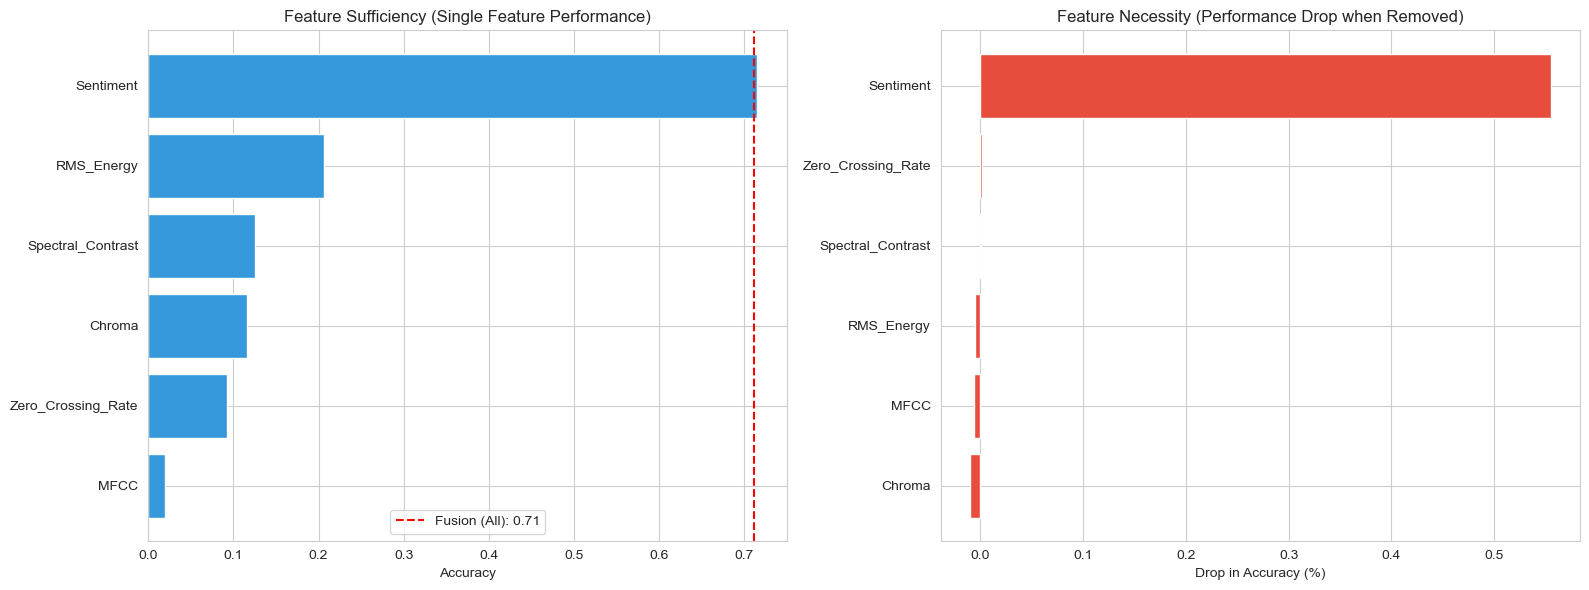


=== ABLATION STUDY RESULTS ===
Feature              | Single Acc | Drop if Removed
--------------------------------------------------
MFCC                 | 0.0192     | -0.0065
Chroma               | 0.1157     | -0.0103
Spectral_Contrast    | 0.1257     | 0.0008
Zero_Crossing_Rate   | 0.0927     | 0.0015
RMS_Energy           | 0.2061     | -0.0054
Sentiment            | 0.7149     | 0.5552


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score
from functions import prepare_datasets, slice_features, build_dynamic_model, Config

def run_ablation_study():
    # 1. Setup
    # Define the full feature set
    ALL_FEATURES = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
    
    # Storage for results
    results_sufficiency = {} # Single Feature
    results_necessity = {}   # Leave-One-Out
    
    # Load Data ONCE (Augmentation OFF for stable comparison)
    print("Loading Dataset...")
    data = prepare_datasets(Config.DEFAULT_CLASSES, augment=False)
    y_true = data['y_test']
    
    # Calculate Class Weights
    cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
    cw_dict = dict(enumerate(cw))

    # ==========================================
    # PHASE 1: BASELINE (ALL FEATURES)
    # ==========================================
    print(f"\n--- Running Baseline (All Features) ---")
    tf.keras.backend.clear_session()
    gc.collect()
    
    inputs, shapes, types = slice_features(data, ALL_FEATURES)
    model = build_dynamic_model(types, shapes, len(Config.DEFAULT_CLASSES), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=12, verbose=0, batch_size=32, class_weight=cw_dict)
    
    y_pred = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    baseline_acc = accuracy_score(y_true, y_pred)
    print(f"Baseline Accuracy: {baseline_acc:.4f}")

    # ==========================================
    # PHASE 2: FEATURE SUFFICIENCY (SINGLE)
    # ==========================================
    print(f"\n--- Phase 2: Feature Sufficiency (Single Feature) ---")
    for feat in ALL_FEATURES:
        print(f"Testing ONLY {feat}...")
        tf.keras.backend.clear_session()
        gc.collect()
        
        # Slice ONLY this feature
        inputs, shapes, types = slice_features(data, [feat])
        
        # Train
        model = build_dynamic_model(types, shapes, len(Config.DEFAULT_CLASSES), data['num_sent_classes'])
        model.fit(inputs['train'], data['y_train'], epochs=12, verbose=0, batch_size=32, class_weight=cw_dict)
        
        # Evaluate
        y_pred = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
        acc = accuracy_score(y_true, y_pred)
        results_sufficiency[feat] = acc
        print(f"   -> Acc: {acc:.4f}")

    # ==========================================
    # PHASE 3: FEATURE NECESSITY (LEAVE-ONE-OUT)
    # ==========================================
    print(f"\n--- Phase 3: Feature Necessity (Leave-One-Out) ---")
    for feat in ALL_FEATURES:
        print(f"Testing ALL EXCEPT {feat}...")
        tf.keras.backend.clear_session()
        gc.collect()
        
        # Define active features (All minus current)
        current_feats = [f for f in ALL_FEATURES if f != feat]
        inputs, shapes, types = slice_features(data, current_feats)
        
        # Train
        model = build_dynamic_model(types, shapes, len(Config.DEFAULT_CLASSES), data['num_sent_classes'])
        model.fit(inputs['train'], data['y_train'], epochs=12, verbose=0, batch_size=32, class_weight=cw_dict)
        
        # Evaluate
        y_pred = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
        acc = accuracy_score(y_true, y_pred)
        results_necessity[f"No {feat}"] = acc
        print(f"   -> Acc: {acc:.4f}")

    # ==========================================
    # VISUALIZATION
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Sufficiency
    df_suff = pd.DataFrame(list(results_sufficiency.items()), columns=['Feature', 'Accuracy'])
    df_suff.sort_values('Accuracy', inplace=True)
    
    axes[0].barh(df_suff['Feature'], df_suff['Accuracy'], color='#3498db')
    axes[0].axvline(baseline_acc, color='r', linestyle='--', label=f'Fusion (All): {baseline_acc:.2f}')
    axes[0].set_title('Feature Sufficiency (Single Feature Performance)')
    axes[0].set_xlabel('Accuracy')
    axes[0].legend()
    
    # Plot 2: Necessity (Drop in performance)
    # Calculate Drop: Baseline - LOO_Result
    drops = {k.replace("No ", ""): baseline_acc - v for k, v in results_necessity.items()}
    df_nec = pd.DataFrame(list(drops.items()), columns=['Feature Removed', 'Performance Drop'])
    df_nec.sort_values('Performance Drop', inplace=True)
    
    axes[1].barh(df_nec['Feature Removed'], df_nec['Performance Drop'], color='#e74c3c')
    axes[1].set_title('Feature Necessity (Performance Drop when Removed)')
    axes[1].set_xlabel('Drop in Accuracy (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Print Table
    print("\n=== ABLATION STUDY RESULTS ===")
    print(f"{'Feature':<20} | {'Single Acc':<10} | {'Drop if Removed':<15}")
    print("-" * 50)
    for feat in ALL_FEATURES:
        single = results_sufficiency.get(feat, 0)
        drop = baseline_acc - results_necessity.get(f"No {feat}", 0)
        print(f"{feat:<20} | {single:.4f}     | {drop:.4f}")

# Run it
run_ablation_study()

In [1]:
from functions import (
    Config,
    prepare_datasets,
    slice_features,
    build_dynamic_model,
    run_experiment_class_optimization,
    run_experiment_feature_ablation,
    plot_feature_correlation,
    plot_class_distribution,
    plot_3d_tsne,
    run_evaluation,
    plot_feature_label_correlation
)

--- Starting Experiment 2: Individual Feature Importance ---
Training models on one feature at a time...

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [05:38<00:00, 29.53it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:29<00:00, 37.61it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:07<00:00, 38.72it/s]




Running: Train_MFCC (Active: ['MFCC'])



 -> Accuracy: 0.3484

Running: Train_Chroma (Active: ['Chroma'])
 -> Accuracy: 0.1164

Running: Train_Spectral_Contrast (Active: ['Spectral_Contrast'])
 -> Accuracy: 0.1679

Running: Train_Zero_Crossing_Rate (Active: ['Zero_Crossing_Rate'])
 -> Accuracy: 0.1309

Running: Train_RMS_Energy (Active: ['RMS_Energy'])
 -> Accuracy: 0.2067

Running: Train_Sentiment (Active: ['Sentiment'])
 -> Accuracy: 0.6065

Running: Train_Fusion_All (Active: ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment'])
 -> Accuracy: 0.6489

=== Feature Experiment Results ===


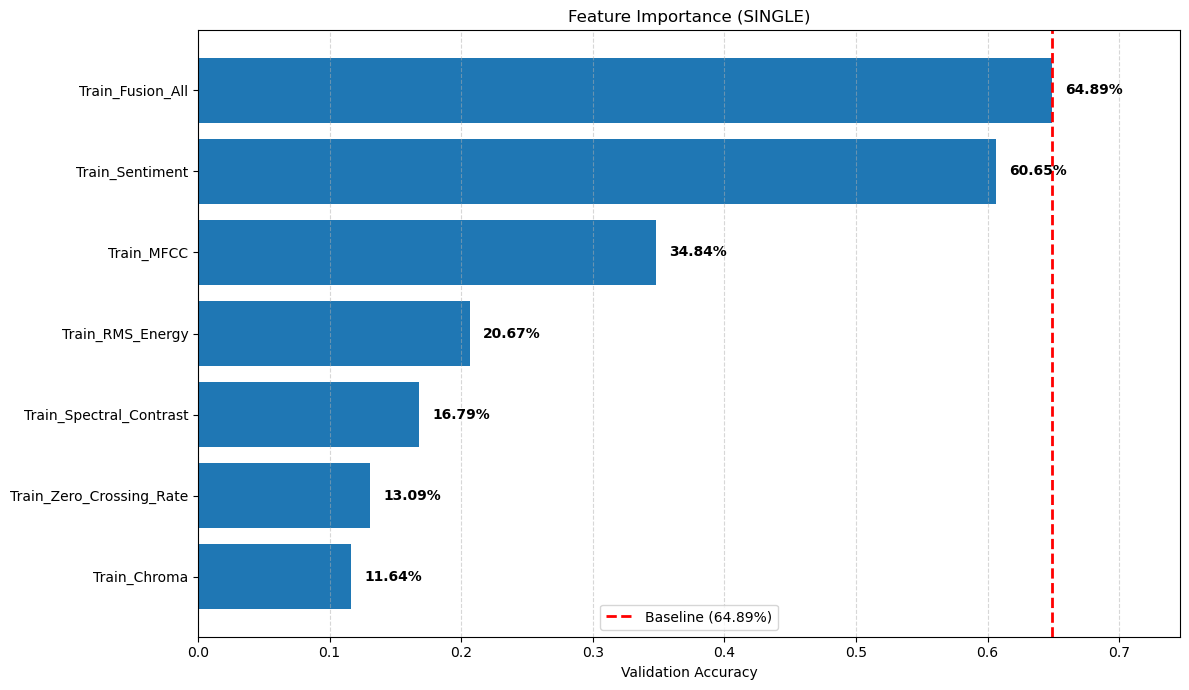

✅ Experiment 2 Completed.


In [2]:
print("--- Starting Experiment 2: Individual Feature Importance ---")
print("Training models on one feature at a time...")

# mode='single' trains on MFCC only, Chroma only, etc.
run_experiment_feature_ablation(mode='single')

print("✅ Experiment 2 Completed.")

--- Starting Experiment 3: Leave-One-Out Ablation ---
Training models by excluding one feature at a time...

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [06:31<00:00, 25.50it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:43<00:00, 25.69it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:28<00:00, 29.65it/s]



Running: Baseline_All (Active: ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment'])
 -> Accuracy: 0.6507

Running: Exclude_MFCC (Active: ['Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment'])
 -> Accuracy: 0.6661

Running: Exclude_Chroma (Active: ['MFCC', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment'])
 -> Accuracy: 0.6688

Running: Exclude_Spectral_Contrast (Active: ['MFCC', 'Chroma', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment'])
 -> Accuracy: 0.6507

Running: Exclude_Zero_Crossing_Rate (Active: ['MFCC', 'Chroma', 'Spectral_Contrast', 'RMS_Energy', 'Sentiment'])
 -> Accuracy: 0.6769

Running: Exclude_RMS_Energy (Active: ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'Sentiment'])
 -> Accuracy: 0.6543

Running: Exclude_Sentiment (Active: ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy'])
 -> Accuracy: 0.1958

=== Feature Experiment Results ===


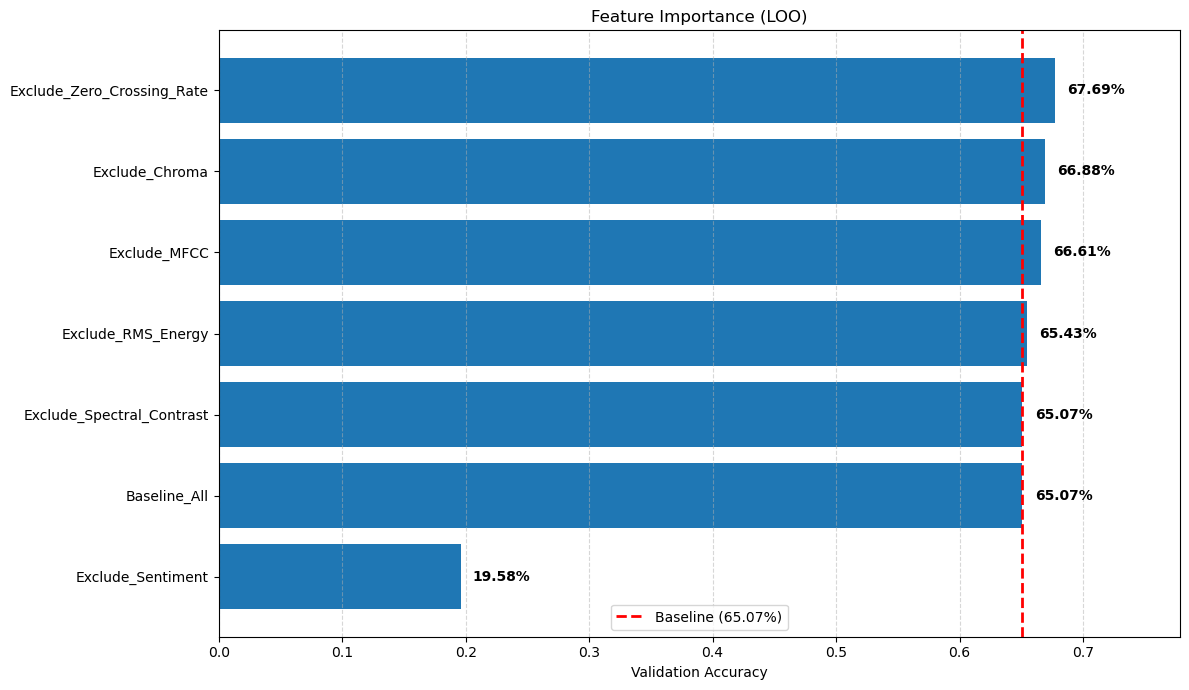

✅ Experiment 3 Completed.


In [3]:
print("--- Starting Experiment 3: Leave-One-Out Ablation ---")
print("Training models by excluding one feature at a time...")

# mode='loo' runs Baseline (All) vs. Exclude MFCC, Exclude Sentiment, etc.
run_experiment_feature_ablation(mode='loo')

print("✅ Experiment 3 Completed.")

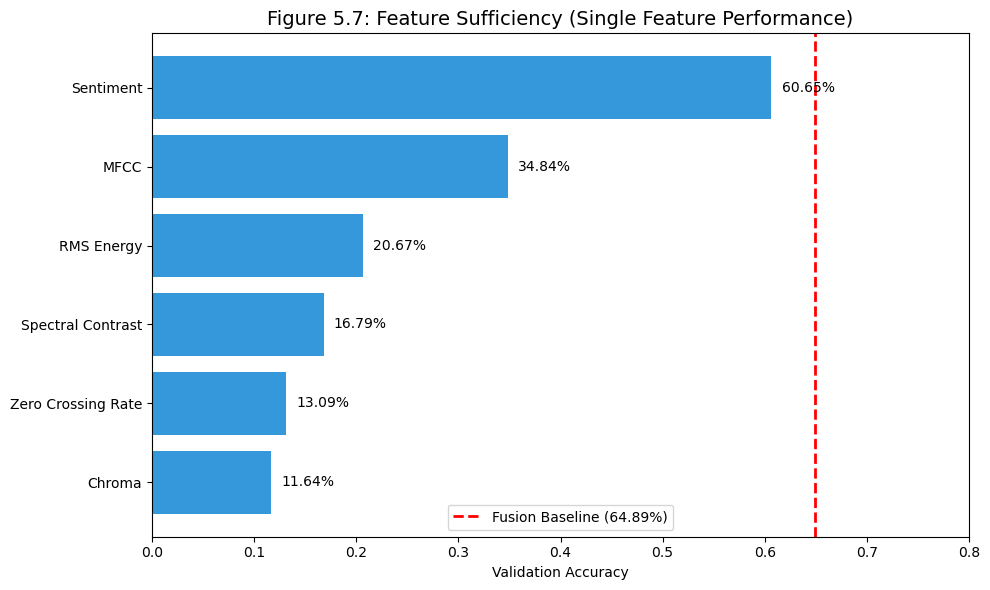

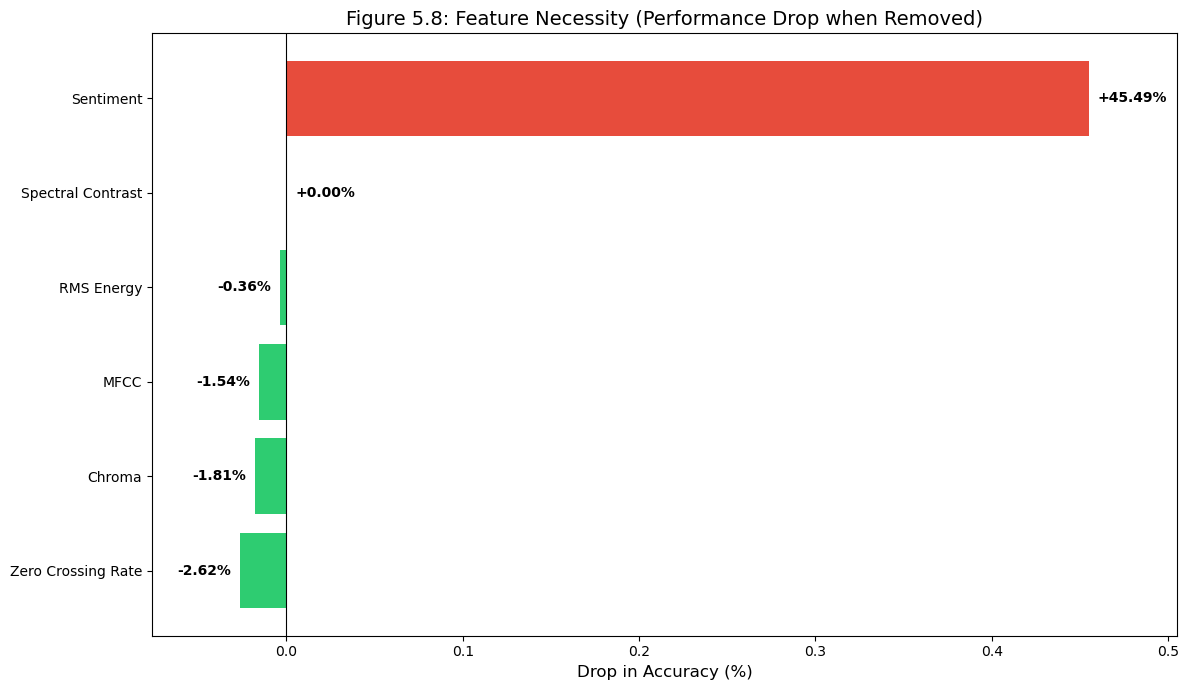

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# 1. SETUP DATA
# ==========================================
# Hardcoded results from your experiments
sufficiency_data = {
    'Sentiment': 0.6065,
    'MFCC': 0.3484,
    'RMS Energy': 0.2067,
    'Spectral Contrast': 0.1679,
    'Zero Crossing Rate': 0.1309,
    'Chroma': 0.1164
}
baseline_suff = 0.6489

necessity_baseline = 0.6507
necessity_results = {
    'Sentiment': 0.1958,
    'MFCC': 0.6661,
    'Chroma': 0.6688,
    'Spectral Contrast': 0.6507,
    'Zero Crossing Rate': 0.6769,
    'RMS Energy': 0.6543
}

# Calculate Drops
drops = {feat: necessity_baseline - acc for feat, acc in necessity_results.items()}

# ==========================================
# 2. PLOT FIGURE 5.7: SUFFICIENCY
# ==========================================
plt.figure(figsize=(10, 6))
sorted_suff = dict(sorted(sufficiency_data.items(), key=lambda item: item[1]))
features_suff = list(sorted_suff.keys())
values_suff = list(sorted_suff.values())

bars_suff = plt.barh(features_suff, values_suff, color='#3498db')
plt.axvline(baseline_suff, color='r', linestyle='--', linewidth=2, label=f'Fusion Baseline ({baseline_suff:.2%})')

# Labels
for bar in bars_suff:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2%}', va='center', fontsize=10)

plt.title('Figure 5.7: Feature Sufficiency (Single Feature Performance)', fontsize=14)
plt.xlabel('Validation Accuracy')
plt.legend()
plt.xlim(0, 0.8) 
plt.tight_layout()
plt.show()

# ==========================================
# 3. PLOT FIGURE 5.8: NECESSITY (FIXED)
# ==========================================
plt.figure(figsize=(12, 7)) # Wider figure to help with spacing

# Sort: Negative drops (Green) at top, Positive drops (Red) at bottom or vice versa
# Let's sort mathematically so the bars flow logically
sorted_drops = dict(sorted(drops.items(), key=lambda item: item[1])) 

features_nec = list(sorted_drops.keys())
values_nec = list(sorted_drops.values())

# Colors
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in values_nec]

bars_nec = plt.barh(features_nec, values_nec, color=colors)

plt.title('Figure 5.8: Feature Necessity (Performance Drop when Removed)', fontsize=14)
plt.xlabel('Drop in Accuracy (%)', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8) 

# --- FIX: DYNAMIC LIMITS ---
# Calculate min and max to set proper margins
min_val = min(values_nec)
max_val = max(values_nec)
# Add extra padding on left (for negative labels) and right (for positive labels)
plt.xlim(min_val - 0.05, max_val + 0.05) 

# Add labels
for bar in bars_nec:
    width = bar.get_width()
    
    # Conditional placement:
    if width < 0:
        # If bar is negative (Green), place text slightly to the LEFT of the bar end
        # The 'padding' logic handles the overlap with Y-axis
        label_x = width - 0.005 
        ha_align = 'right' # Align text end to this point
    else:
        # If bar is positive (Red), place text slightly to the RIGHT
        label_x = width + 0.005
        ha_align = 'left'

    plt.text(label_x, 
             bar.get_y() + bar.get_height()/2, 
             f'{width:+.2%}', 
             va='center', 
             ha=ha_align, 
             fontsize=10, 
             fontweight='bold',
             color='black')

plt.tight_layout()
plt.show()

## Experiment I: Baseline (7 Classes)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from sklearn.utils import class_weight
from tf_keras import callbacks
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
# Ensure 'functions.py' is in your directory
from functions import prepare_datasets, slice_features, build_dynamic_model, Config

# 1. Prepare Data (Keep All Classes)
current_classes = Config.DEFAULT_CLASSES
print(f"Target Classes: {current_classes}")

# Load Data (Augmentation OFF for stable comparison)
data = prepare_datasets(current_classes, augment=False)

# 2. Features (Using All Features)
feats = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
inputs, shapes, types = slice_features(data, feats)

Target Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust']

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 9988 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9988/9988 [07:21<00:00, 22.63it/s]


Processing 1108 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1108/1108 [00:47<00:00, 23.27it/s]


Processing 2610 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2610/2610 [01:52<00:00, 23.23it/s]


In [23]:
EXP_NAME = "Experiment I (7 Classes)"
DROP_CLASS = None # Keep all classes

print(f"\n{'='*60}\nRunning {EXP_NAME}\n{'='*60}")
# 3. Train Model
tf.keras.backend.clear_session()
gc.collect()

model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])

print("Training model...")
history = model.fit(inputs['train'], data['y_train'],
                    validation_data=(inputs['dev'], data['y_dev']),
                    epochs=40, verbose=1, batch_size=32, 
                    class_weight=dict(enumerate(cw)),
                    callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)])


Running Experiment I (7 Classes)
Training model...
Epoch 1/40
313/313 [==============================] - 12s 22ms/step - loss: 1.6454 - accuracy: 0.5200 - val_loss: 0.7479 - val_accuracy: 0.6634
Epoch 2/40
313/313 [==============================] - 6s 19ms/step - loss: 1.1895 - accuracy: 0.7033 - val_loss: 0.7296 - val_accuracy: 0.6751
Epoch 3/40
313/313 [==============================] - 6s 20ms/step - loss: 1.1586 - accuracy: 0.7103 - val_loss: 0.7239 - val_accuracy: 0.6877
Epoch 4/40
313/313 [==============================] - 7s 21ms/step - loss: 1.1171 - accuracy: 0.7219 - val_loss: 0.7305 - val_accuracy: 0.6679
Epoch 5/40
313/313 [==============================] - 6s 19ms/step - loss: 1.1134 - accuracy: 0.7223 - val_loss: 0.7344 - val_accuracy: 0.6697
Epoch 6/40
313/313 [==============================] - 6s 19ms/step - loss: 1.1020 - accuracy: 0.7301 - val_loss: 0.7324 - val_accuracy: 0.6390
Epoch 7/40
313/313 [==============================] - 6s 19ms/step - loss: 1.0948 - accur

Evaluating on Test Set...

>>> Results for Experiment I (7 Classes)
Accuracy: 0.7241
Macro F1: 0.4216
Macro Recall: 0.4501

>>> Classification Report
              precision    recall  f1-score   support

       anger     0.4636    0.3507    0.3993       345
     disgust     0.1250    0.2500    0.1667        68
        fear     0.0375    0.1200    0.0571        50
         joy     0.7816    0.9701    0.8657       402
     neutral     1.0000    1.0000    1.0000      1256
     sadness     0.3217    0.3990    0.3562       208
    surprise     0.4250    0.0605    0.1059       281

    accuracy                         0.7241      2610
   macro avg     0.4506    0.4501    0.4216      2610
weighted avg     0.7383    0.7241    0.7126      2610



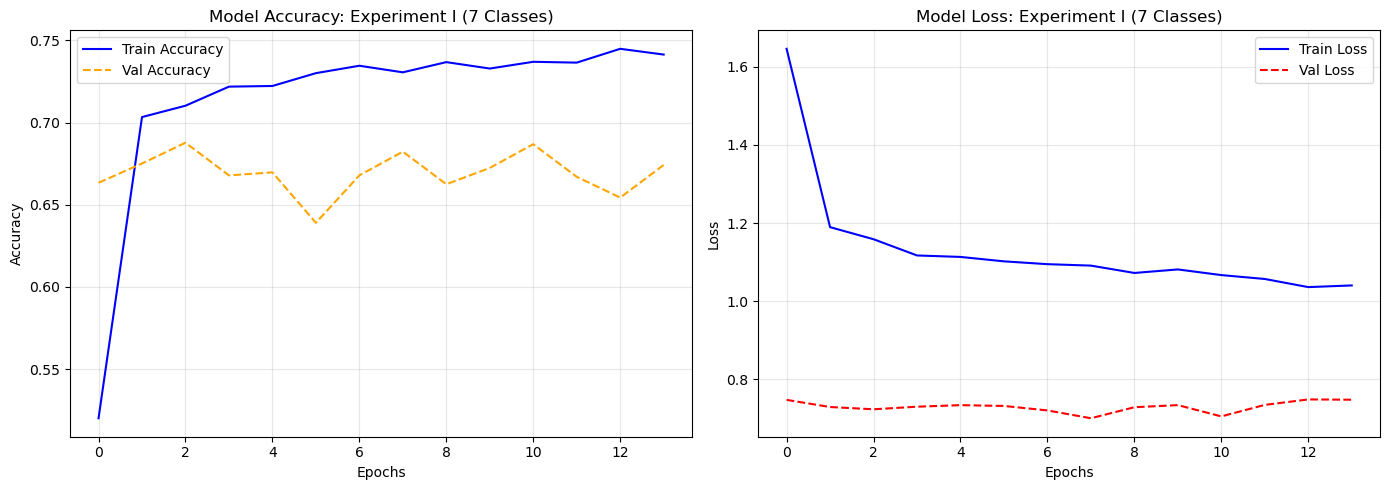

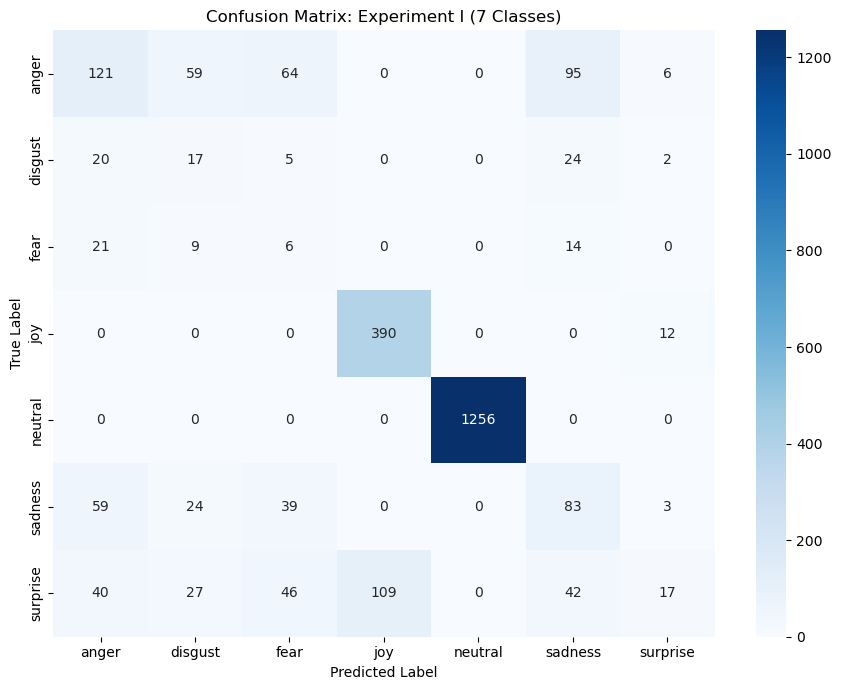

In [24]:
# 4. Evaluate
print("Evaluating on Test Set...")
y_pred_probs = model.predict(inputs['test'], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = data['y_test']

# Metrics
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')

print(f"\n>>> Results for {EXP_NAME}")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"Macro Recall: {rec:.4f}")

# --- DISPLAY CLASSIFICATION REPORT ---
print("\n>>> Classification Report")
class_names = data['le_target'].classes_
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# --- A. Training Curves (Accuracy & Loss) ---
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
plt.title(f'Model Accuracy: {EXP_NAME}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title(f'Model Loss: {EXP_NAME}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- PLOT CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title(f'Confusion Matrix: {EXP_NAME}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [28]:
ALL_FEATURES = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
# Store results here
results_sufficiency = {}
results_necessity = {}
baseline_acc = 0.7241

print(f"\n{'='*40}\nPART 2: Feature Sufficiency (Single Feature)\n{'='*40}")
for feat in ALL_FEATURES:
    print(f"Training ONLY {feat}...")
    tf.keras.backend.clear_session()
    gc.collect()
    
    inputs, shapes, types = slice_features(data, [feat])
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=15, verbose=0, batch_size=32, class_weight=dict(enumerate(cw)))
    
    y_p = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    acc = accuracy_score(y_true, y_p)
    results_sufficiency[feat] = acc
    print(f"   -> Acc: {acc:.4f}")


PART 2: Feature Sufficiency (Single Feature)
Training ONLY MFCC...
   -> Acc: 0.4801
Training ONLY Chroma...
   -> Acc: 0.0946
Training ONLY Spectral_Contrast...
   -> Acc: 0.1360
Training ONLY Zero_Crossing_Rate...
   -> Acc: 0.1192
Training ONLY RMS_Energy...
   -> Acc: 0.1226
Training ONLY Sentiment...
   -> Acc: 0.6544


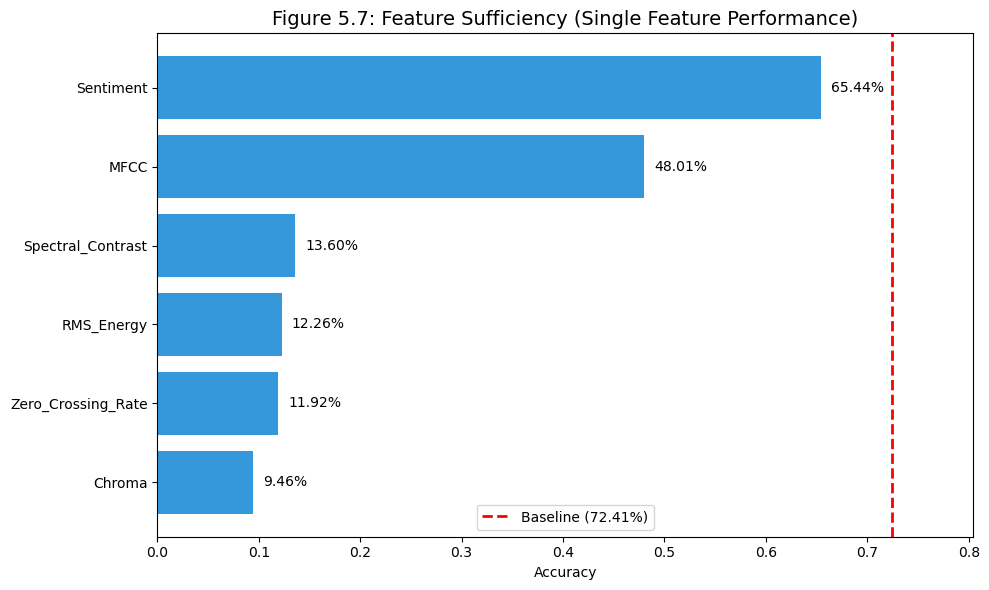

In [29]:
# --- Figure 5.7: Sufficiency ---
plt.figure(figsize=(10, 6))
sorted_suff = dict(sorted(results_sufficiency.items(), key=lambda item: item[1]))
bars_suff = plt.barh(list(sorted_suff.keys()), list(sorted_suff.values()), color='#3498db')
plt.axvline(baseline_acc, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.2%})')

for bar in bars_suff:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2%}', va='center', fontsize=10)
             
plt.title('Figure 5.7: Feature Sufficiency (Single Feature Performance)', fontsize=14)
plt.xlabel('Accuracy')
plt.legend()
plt.xlim(0, max(results_sufficiency.values()) + 0.15) 
plt.tight_layout()
plt.show()

In [30]:
print(f"\n{'='*40}\nPART 3: Feature Necessity (Leave-One-Out)\n{'='*40}")
for feat in ALL_FEATURES:
    print(f"Training WITHOUT {feat}...")
    tf.keras.backend.clear_session()
    gc.collect()
    
    active = [f for f in ALL_FEATURES if f != feat]
    inputs, shapes, types = slice_features(data, active)
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=15, verbose=0, batch_size=32, class_weight=dict(enumerate(cw)))
    
    y_p = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    acc = accuracy_score(y_true, y_p)
    results_necessity[feat] = acc
    print(f"   -> Acc: {acc:.4f}")


PART 3: Feature Necessity (Leave-One-Out)
Training WITHOUT MFCC...
   -> Acc: 0.6736
Training WITHOUT Chroma...
   -> Acc: 0.6931
Training WITHOUT Spectral_Contrast...
   -> Acc: 0.6839
Training WITHOUT Zero_Crossing_Rate...
   -> Acc: 0.7092
Training WITHOUT RMS_Energy...
   -> Acc: 0.7103
Training WITHOUT Sentiment...
   -> Acc: 0.1134


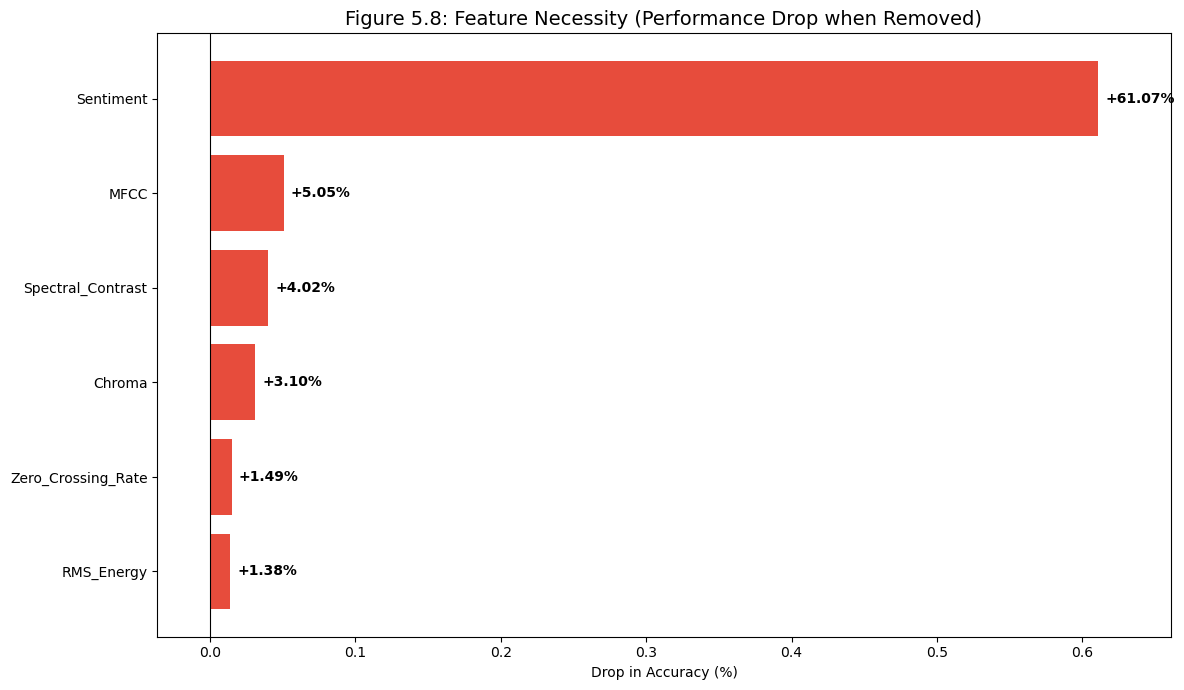

In [31]:
# --- Figure 5.8: Necessity ---
drops = {k: baseline_acc - v for k, v in results_necessity.items()}
sorted_drops = dict(sorted(drops.items(), key=lambda item: item[1]))

plt.figure(figsize=(12, 7))
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in sorted_drops.values()]
bars_nec = plt.barh(list(sorted_drops.keys()), list(sorted_drops.values()), color=colors)
plt.axvline(0, color='black', linewidth=0.8)

# Dynamic Limits
vals = list(sorted_drops.values())
plt.xlim(min(vals) - 0.05, max(vals) + 0.05)

for bar in bars_nec:
    w = bar.get_width()
    label_x = w - 0.005 if w < 0 else w + 0.005
    align = 'right' if w < 0 else 'left'
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{w:+.2%}', va='center', ha=align, fontsize=10, fontweight='bold')

plt.title('Figure 5.8: Feature Necessity (Performance Drop when Removed)', fontsize=14)
plt.xlabel('Drop in Accuracy (%)')
plt.tight_layout()
plt.show()

## Experiment II (Ekman's 6 Basic Emotions)


Running Experiment II (Ekman's 6 Basic Emotions)
Target Classes: ['joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust']

--- Preparing Data for Classes: ['joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust'] ---
Processing 5279 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 5279/5279 [02:40<00:00, 32.98it/s]


Processing 639 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|████████████████████████████████████████████████████████████████████████████████| 639/639 [00:22<00:00, 29.01it/s]


Processing 1354 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1354/1354 [00:37<00:00, 35.72it/s]


Training model...
Epoch 1/40
165/165 [==============================] - 9s 23ms/step - loss: 1.7252 - accuracy: 0.3209 - val_loss: 1.3100 - val_accuracy: 0.4210
Epoch 2/40
165/165 [==============================] - 3s 17ms/step - loss: 1.3902 - accuracy: 0.4531 - val_loss: 1.2544 - val_accuracy: 0.4069
Epoch 3/40
165/165 [==============================] - 3s 17ms/step - loss: 1.3452 - accuracy: 0.4671 - val_loss: 1.2503 - val_accuracy: 0.4210
Epoch 4/40
165/165 [==============================] - 3s 17ms/step - loss: 1.3130 - accuracy: 0.4776 - val_loss: 1.2476 - val_accuracy: 0.4554
Epoch 5/40
165/165 [==============================] - 3s 17ms/step - loss: 1.2989 - accuracy: 0.4870 - val_loss: 1.2551 - val_accuracy: 0.4444
Epoch 6/40
165/165 [==============================] - 3s 17ms/step - loss: 1.2904 - accuracy: 0.4848 - val_loss: 1.2360 - val_accuracy: 0.4257
Epoch 7/40
165/165 [==============================] - 3s 17ms/step - loss: 1.2793 - accuracy: 0.4935 - val_loss: 1.2404 - va

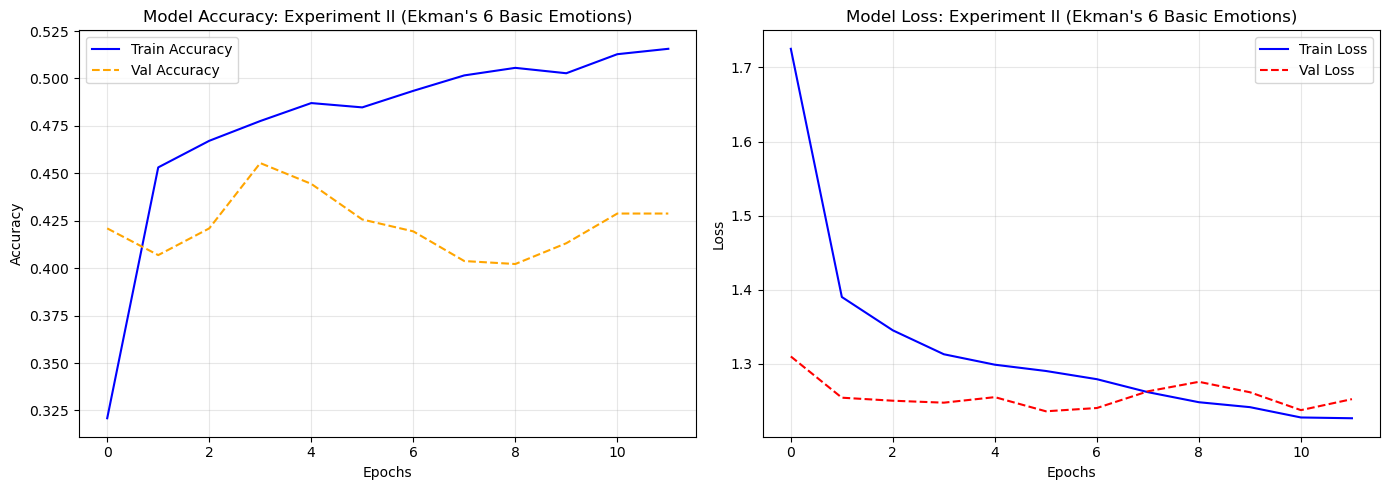

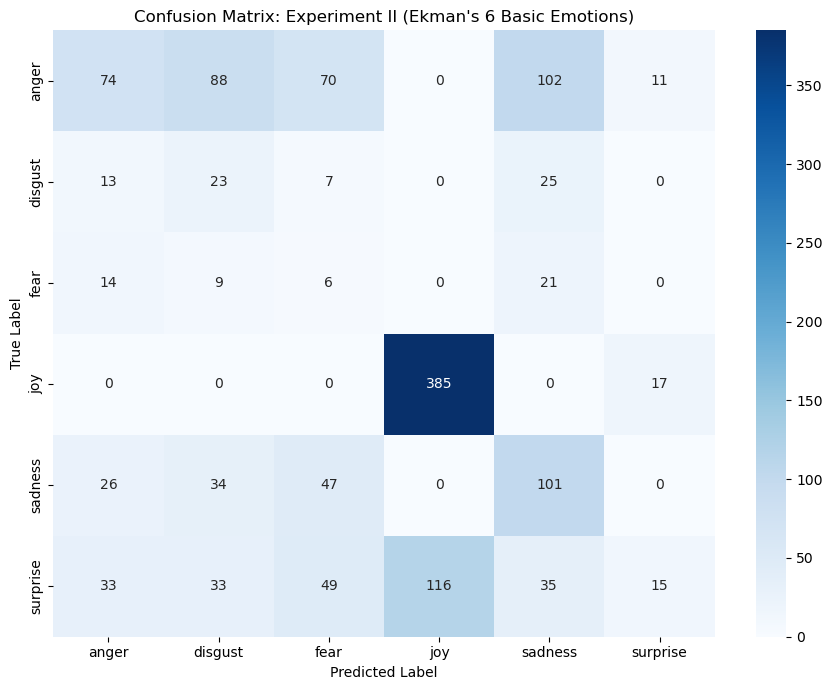

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from functions import prepare_datasets, slice_features, build_dynamic_model, Config

def run_experiment_II():
    EXP_NAME = "Experiment II (Ekman's 6 Basic Emotions)"
    
    print(f"\n{'='*60}\nRunning {EXP_NAME}\n{'='*60}")
    
    # 1. Prepare Data (Exclude 'neutral')
    # Ekman's 6: Joy, Sadness, Anger, Fear, Disgust, Surprise
    current_classes = ['joy', 'sadness', 'anger', 'surprise', 'fear', 'disgust']
    print(f"Target Classes: {current_classes}")
    
    # Load Data
    data = prepare_datasets(current_classes, augment=False)
    
    # 2. Features (Using All Features)
    feats = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
    inputs, shapes, types = slice_features(data, feats)
    
    # 3. Train Model
    tf.keras.backend.clear_session()
    gc.collect()
    
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
    
    print("Training model...")
    history = model.fit(inputs['train'], data['y_train'], 
                        validation_data=(inputs['dev'], data['y_dev']), 
                        epochs=40, verbose=1, batch_size=32, 
                        class_weight=dict(enumerate(cw)),
                        callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
    
    # 4. Evaluate on Test Set
    print("Evaluating on Test Set...")
    y_pred_probs = model.predict(inputs['test'], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = data['y_test']
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    
    print(f"\n>>> Results for {EXP_NAME}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    
    print("\n>>> Classification Report")
    class_names = data['le_target'].classes_
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # ==========================================
    # 5. VISUALIZATION
    # ==========================================
    
    # --- A. Training Curves ---
    plt.figure(figsize=(14, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
    plt.title(f'Model Accuracy: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
    plt.title(f'Model Loss: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- B. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title(f'Confusion Matrix: {EXP_NAME}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment_II()


PART 2: Feature Sufficiency (Single Feature)
Training ONLY MFCC...
   -> Acc: 0.4379
Training ONLY Chroma...
   -> Acc: 0.1153
Training ONLY Spectral_Contrast...
   -> Acc: 0.1195
Training ONLY Zero_Crossing_Rate...
   -> Acc: 0.1360
Training ONLY RMS_Energy...
   -> Acc: 0.1103
Training ONLY Sentiment...
   -> Acc: 0.7674


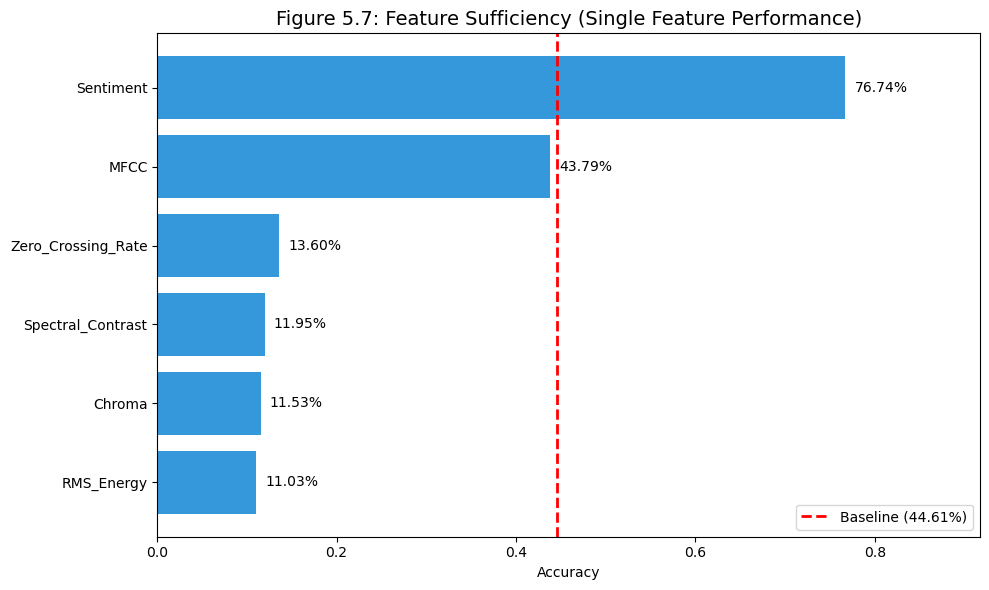

In [33]:
ALL_FEATURES = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
# Store results here
results_sufficiency = {}
results_necessity = {}
baseline_acc = 0.4461

print(f"\n{'='*40}\nPART 2: Feature Sufficiency (Single Feature)\n{'='*40}")
for feat in ALL_FEATURES:
    print(f"Training ONLY {feat}...")
    tf.keras.backend.clear_session()
    gc.collect()
    
    inputs, shapes, types = slice_features(data, [feat])
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=15, verbose=0, batch_size=32, class_weight=dict(enumerate(cw)))
    
    y_p = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    acc = accuracy_score(y_true, y_p)
    results_sufficiency[feat] = acc
    print(f"   -> Acc: {acc:.4f}")

# --- Figure 5.7: Sufficiency ---
plt.figure(figsize=(10, 6))
sorted_suff = dict(sorted(results_sufficiency.items(), key=lambda item: item[1]))
bars_suff = plt.barh(list(sorted_suff.keys()), list(sorted_suff.values()), color='#3498db')
plt.axvline(baseline_acc, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.2%})')

for bar in bars_suff:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2%}', va='center', fontsize=10)
             
plt.title('Figure 5.7: Feature Sufficiency (Single Feature Performance)', fontsize=14)
plt.xlabel('Accuracy')
plt.legend()
plt.xlim(0, max(results_sufficiency.values()) + 0.15) 
plt.tight_layout()
plt.show()


PART 3: Feature Necessity (Leave-One-Out)
Training WITHOUT MFCC...
   -> Acc: 0.7027
Training WITHOUT Chroma...
   -> Acc: 0.7134
Training WITHOUT Spectral_Contrast...
   -> Acc: 0.7456
Training WITHOUT Zero_Crossing_Rate...
   -> Acc: 0.7100
Training WITHOUT RMS_Energy...
   -> Acc: 0.6916
Training WITHOUT Sentiment...
   -> Acc: 0.1602


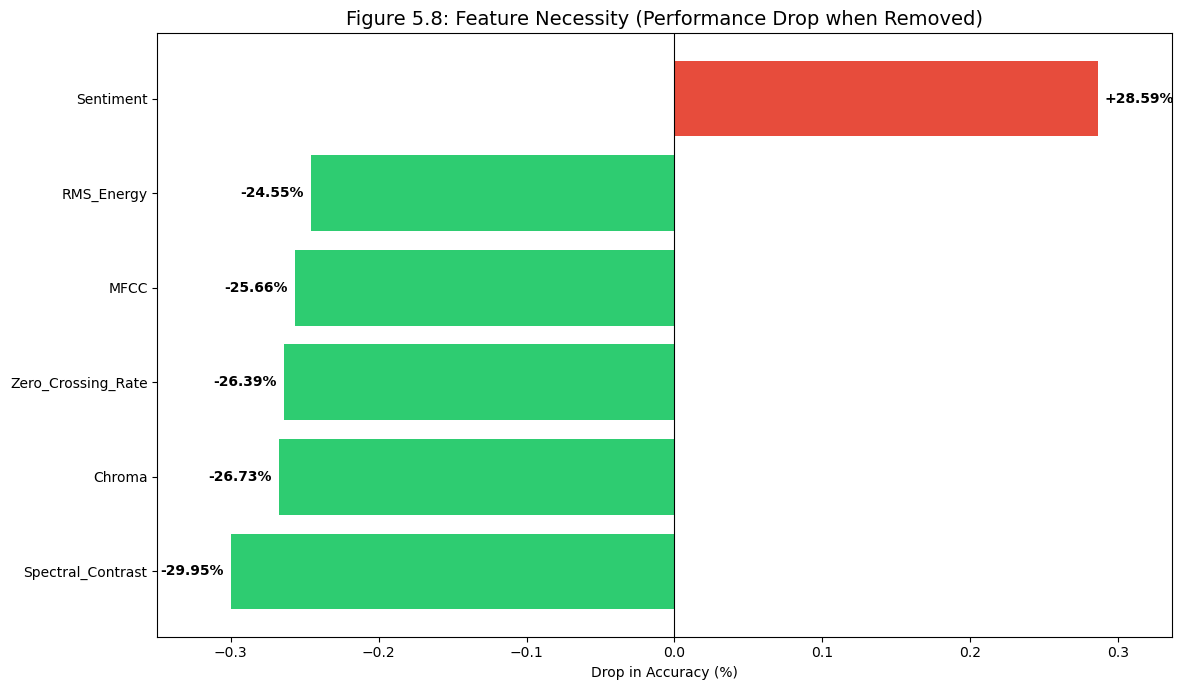

In [34]:
print(f"\n{'='*40}\nPART 3: Feature Necessity (Leave-One-Out)\n{'='*40}")
for feat in ALL_FEATURES:
    print(f"Training WITHOUT {feat}...")
    tf.keras.backend.clear_session()
    gc.collect()
    
    active = [f for f in ALL_FEATURES if f != feat]
    inputs, shapes, types = slice_features(data, active)
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=15, verbose=0, batch_size=32, class_weight=dict(enumerate(cw)))
    
    y_p = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    acc = accuracy_score(y_true, y_p)
    results_necessity[feat] = acc
    print(f"   -> Acc: {acc:.4f}")

# --- Figure 5.8: Necessity ---
drops = {k: baseline_acc - v for k, v in results_necessity.items()}
sorted_drops = dict(sorted(drops.items(), key=lambda item: item[1]))

plt.figure(figsize=(12, 7))
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in sorted_drops.values()]
bars_nec = plt.barh(list(sorted_drops.keys()), list(sorted_drops.values()), color=colors)
plt.axvline(0, color='black', linewidth=0.8)

# Dynamic Limits
vals = list(sorted_drops.values())
plt.xlim(min(vals) - 0.05, max(vals) + 0.05)

for bar in bars_nec:
    w = bar.get_width()
    label_x = w - 0.005 if w < 0 else w + 0.005
    align = 'right' if w < 0 else 'left'
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{w:+.2%}', va='center', ha=align, fontsize=10, fontweight='bold')

plt.title('Figure 5.8: Feature Necessity (Performance Drop when Removed)', fontsize=14)
plt.xlabel('Drop in Accuracy (%)')
plt.tight_layout()
plt.show()

## Experiment III (Drop Surprise)


Running Experiment III (Drop Surprise)
Target Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust'] ---
Processing 8783 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 8783/8783 [05:53<00:00, 24.85it/s]


Processing 958 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|████████████████████████████████████████████████████████████████████████████████| 958/958 [00:59<00:00, 16.09it/s]


Processing 2329 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2329/2329 [02:54<00:00, 13.37it/s]


Training model...
Epoch 1/40
275/275 [==============================] - 28s 57ms/step - loss: 1.4556 - accuracy: 0.6084 - val_loss: 0.4990 - val_accuracy: 0.7453
Epoch 2/40
275/275 [==============================] - 15s 55ms/step - loss: 0.9560 - accuracy: 0.8231 - val_loss: 0.5143 - val_accuracy: 0.7296
Epoch 3/40
275/275 [==============================] - 11s 40ms/step - loss: 0.9199 - accuracy: 0.8223 - val_loss: 0.4749 - val_accuracy: 0.7557
Epoch 4/40
275/275 [==============================] - 11s 40ms/step - loss: 0.9000 - accuracy: 0.8250 - val_loss: 0.4312 - val_accuracy: 0.8132
Epoch 5/40
275/275 [==============================] - 11s 40ms/step - loss: 0.8865 - accuracy: 0.8297 - val_loss: 0.4780 - val_accuracy: 0.7589
Epoch 6/40
275/275 [==============================] - 11s 40ms/step - loss: 0.8777 - accuracy: 0.8354 - val_loss: 0.4962 - val_accuracy: 0.7411
Epoch 7/40
275/275 [==============================] - 11s 41ms/step - loss: 0.8678 - accuracy: 0.8338 - val_loss: 0.48

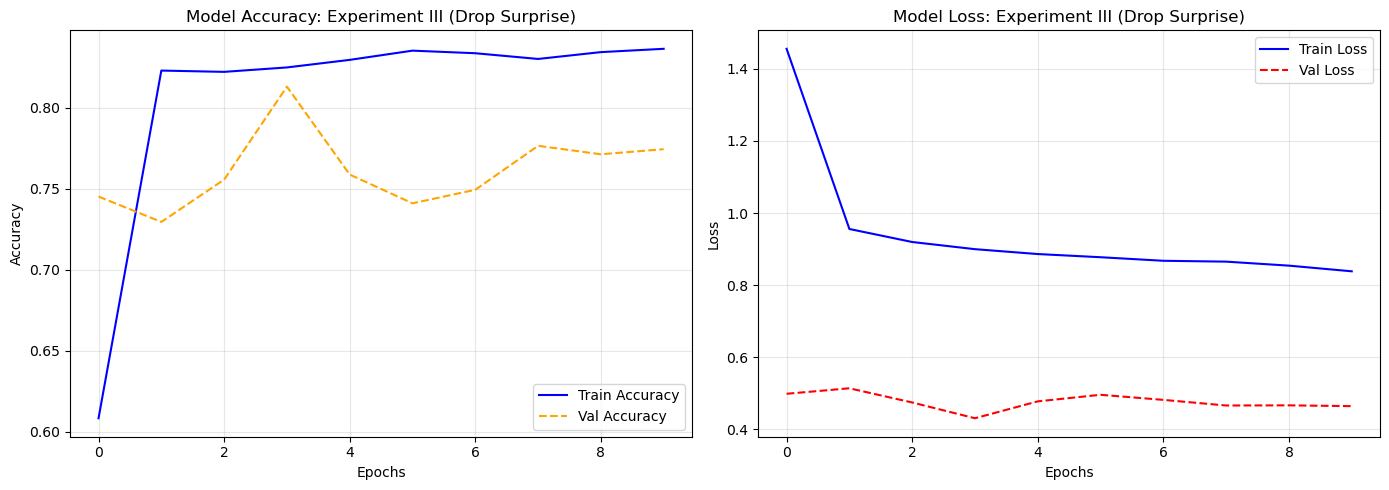

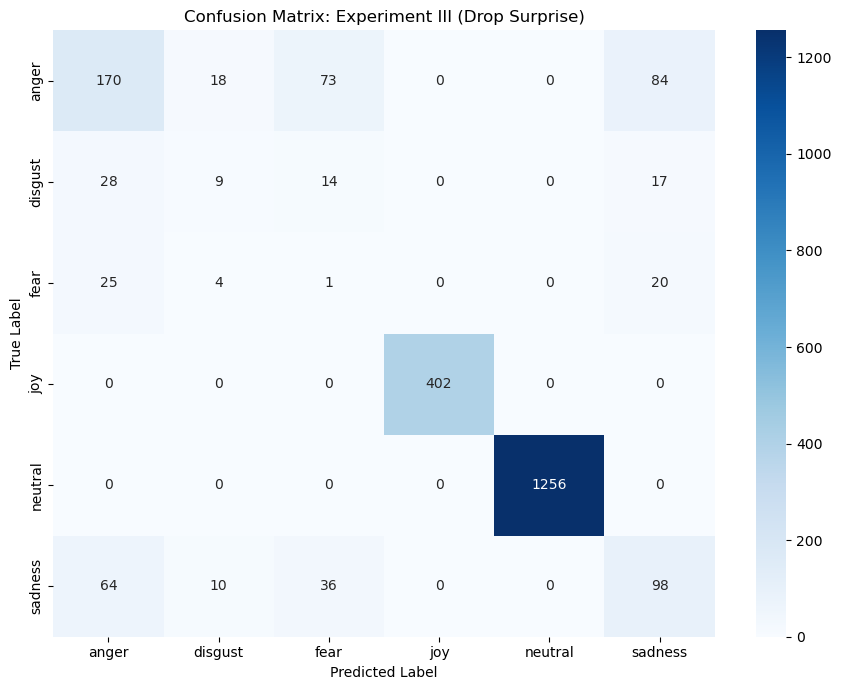

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from functions import prepare_datasets, slice_features, build_dynamic_model, Config

def run_experiment_III():
    EXP_NAME = "Experiment III (Drop Surprise)"
    
    print(f"\n{'='*60}\nRunning {EXP_NAME}\n{'='*60}")
    
    # 1. Prepare Data (Exclude 'neutral')
    # Ekman's 6: Joy, Sadness, Anger, Fear, Disgust, Surprise
    current_classes = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust']
    print(f"Target Classes: {current_classes}")
    
    # Load Data
    data = prepare_datasets(current_classes, augment=False)
    
    # 2. Features (Using All Features)
    feats = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
    inputs, shapes, types = slice_features(data, feats)
    
    # 3. Train Model
    tf.keras.backend.clear_session()
    gc.collect()
    
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
    
    print("Training model...")
    history = model.fit(inputs['train'], data['y_train'], 
                        validation_data=(inputs['dev'], data['y_dev']), 
                        epochs=40, verbose=1, batch_size=32, 
                        class_weight=dict(enumerate(cw)),
                        callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
    
    # 4. Evaluate on Test Set
    print("Evaluating on Test Set...")
    y_pred_probs = model.predict(inputs['test'], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = data['y_test']
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    
    print(f"\n>>> Results for {EXP_NAME}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    
    print("\n>>> Classification Report")
    class_names = data['le_target'].classes_
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # ==========================================
    # 5. VISUALIZATION
    # ==========================================
    
    # --- A. Training Curves ---
    plt.figure(figsize=(14, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
    plt.title(f'Model Accuracy: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
    plt.title(f'Model Loss: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- B. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title(f'Confusion Matrix: {EXP_NAME}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment_III()


PART 2: Feature Sufficiency (Single Feature)
Training ONLY MFCC...
   -> Acc: 0.3330
Training ONLY Chroma...
   -> Acc: 0.1253
Training ONLY Spectral_Contrast...
   -> Acc: 0.1989
Training ONLY Zero_Crossing_Rate...
   -> Acc: 0.1533
Training ONLY RMS_Energy...
   -> Acc: 0.1858
Training ONLY Sentiment...
   -> Acc: 0.6613


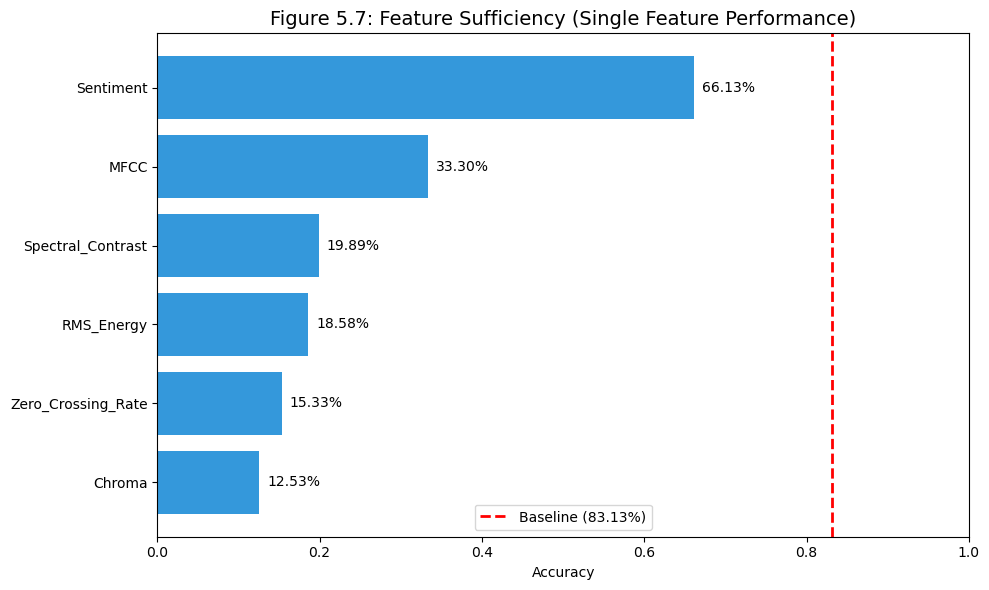

In [41]:
ALL_FEATURES = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
# Store results here
results_sufficiency = {}
results_necessity = {}
baseline_acc = 0.8313

print(f"\n{'='*40}\nPART 2: Feature Sufficiency (Single Feature)\n{'='*40}")
for feat in ALL_FEATURES:
    print(f"Training ONLY {feat}...")
    tf.keras.backend.clear_session()
    gc.collect()
    
    inputs, shapes, types = slice_features(data, [feat])
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=15, verbose=0, batch_size=32, class_weight=dict(enumerate(cw)))
    
    y_p = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    acc = accuracy_score(y_true, y_p)
    results_sufficiency[feat] = acc
    print(f"   -> Acc: {acc:.4f}")

# --- Figure 5.7: Sufficiency ---
plt.figure(figsize=(10, 6))
sorted_suff = dict(sorted(results_sufficiency.items(), key=lambda item: item[1]))
bars_suff = plt.barh(list(sorted_suff.keys()), list(sorted_suff.values()), color='#3498db')
plt.axvline(baseline_acc, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.2%})')

for bar in bars_suff:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2%}', va='center', fontsize=10)
             
plt.title('Figure 5.7: Feature Sufficiency (Single Feature Performance)', fontsize=14)
plt.xlabel('Accuracy')
plt.legend()
plt.xlim(0, 1.0) 
plt.tight_layout()
plt.show()


PART 3: Feature Necessity (Leave-One-Out)
Training WITHOUT MFCC...
   -> Acc: 0.6958
Training WITHOUT Chroma...
   -> Acc: 0.6897
Training WITHOUT Spectral_Contrast...
   -> Acc: 0.7180
Training WITHOUT Zero_Crossing_Rate...
   -> Acc: 0.7360
Training WITHOUT RMS_Energy...
   -> Acc: 0.7142
Training WITHOUT Sentiment...
   -> Acc: 0.1732


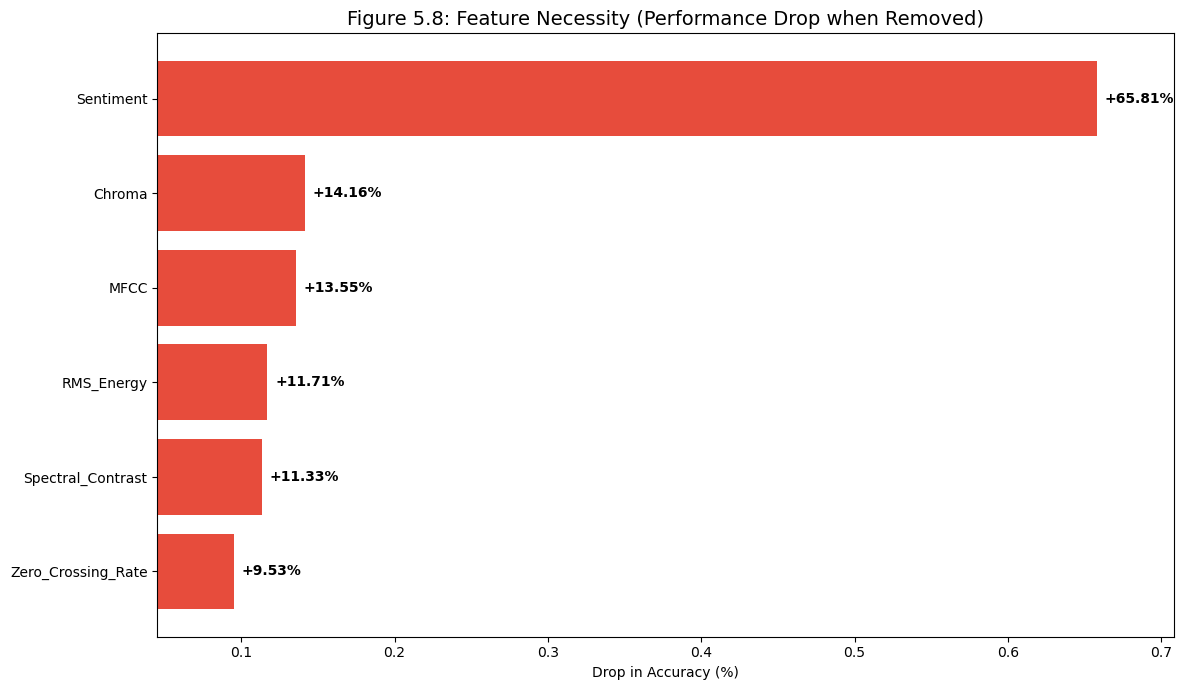

In [39]:
print(f"\n{'='*40}\nPART 3: Feature Necessity (Leave-One-Out)\n{'='*40}")
for feat in ALL_FEATURES:
    print(f"Training WITHOUT {feat}...")
    tf.keras.backend.clear_session()
    gc.collect()
    
    active = [f for f in ALL_FEATURES if f != feat]
    inputs, shapes, types = slice_features(data, active)
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    
    model.fit(inputs['train'], data['y_train'], epochs=15, verbose=0, batch_size=32, class_weight=dict(enumerate(cw)))
    
    y_p = np.argmax(model.predict(inputs['test'], verbose=0), axis=1)
    acc = accuracy_score(y_true, y_p)
    results_necessity[feat] = acc
    print(f"   -> Acc: {acc:.4f}")

# --- Figure 5.8: Necessity ---
drops = {k: baseline_acc - v for k, v in results_necessity.items()}
sorted_drops = dict(sorted(drops.items(), key=lambda item: item[1]))

plt.figure(figsize=(12, 7))
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in sorted_drops.values()]
bars_nec = plt.barh(list(sorted_drops.keys()), list(sorted_drops.values()), color=colors)
plt.axvline(0, color='black', linewidth=0.8)

# Dynamic Limits
vals = list(sorted_drops.values())
plt.xlim(min(vals) - 0.05, max(vals) + 0.05)

for bar in bars_nec:
    w = bar.get_width()
    label_x = w - 0.005 if w < 0 else w + 0.005
    align = 'right' if w < 0 else 'left'
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{w:+.2%}', va='center', ha=align, fontsize=10, fontweight='bold')

plt.title('Figure 5.8: Feature Necessity (Performance Drop when Removed)', fontsize=14)
plt.xlabel('Drop in Accuracy (%)')
plt.tight_layout()
plt.show()

## Experiment IV (Drop Fear)


Running Experiment IV (Drop Fear)
Target Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'disgust']

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'disgust'] ---
Processing 9720 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9720/9720 [18:12<00:00,  8.90it/s]


Processing 1068 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1068/1068 [01:39<00:00, 10.77it/s]


Processing 2560 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2560/2560 [03:40<00:00, 11.62it/s]


Training model...
Epoch 1/40
304/304 [==============================] - 30s 65ms/step - loss: 1.4025 - accuracy: 0.5758 - val_loss: 0.6196 - val_accuracy: 0.7200
Epoch 2/40
304/304 [==============================] - 20s 66ms/step - loss: 0.9783 - accuracy: 0.7388 - val_loss: 0.6122 - val_accuracy: 0.7313
Epoch 3/40
304/304 [==============================] - 17s 57ms/step - loss: 0.9402 - accuracy: 0.7530 - val_loss: 0.6042 - val_accuracy: 0.7022
Epoch 4/40
304/304 [==============================] - 20s 67ms/step - loss: 0.9271 - accuracy: 0.7515 - val_loss: 0.6194 - val_accuracy: 0.6891
Epoch 5/40
304/304 [==============================] - 18s 61ms/step - loss: 0.9055 - accuracy: 0.7607 - val_loss: 0.6346 - val_accuracy: 0.6835
Epoch 6/40
304/304 [==============================] - 15s 49ms/step - loss: 0.9033 - accuracy: 0.7582 - val_loss: 0.6046 - val_accuracy: 0.7135
Epoch 7/40
304/304 [==============================] - 16s 52ms/step - loss: 0.8904 - accuracy: 0.7666 - val_loss: 0.60

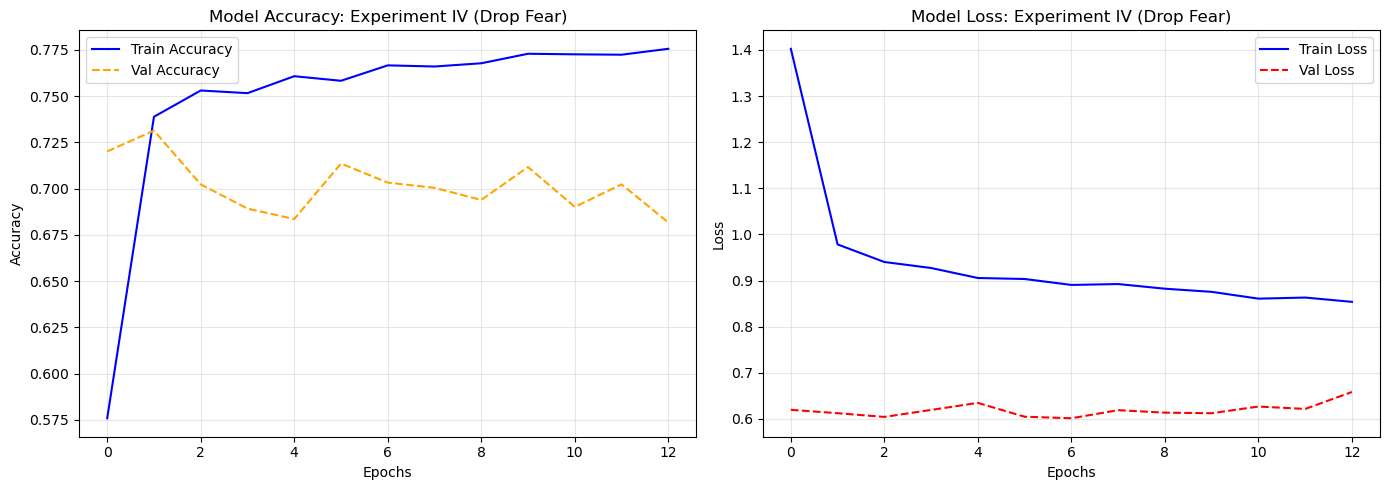

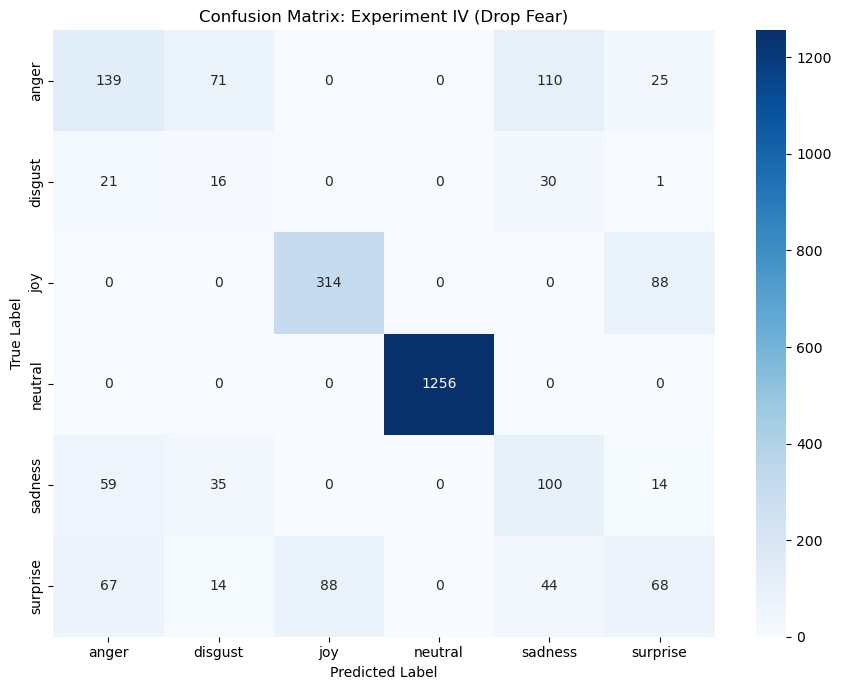

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from functions import prepare_datasets, slice_features, build_dynamic_model, Config

def run_experiment_IV():
    EXP_NAME = "Experiment IV (Drop Fear)"
    
    print(f"\n{'='*60}\nRunning {EXP_NAME}\n{'='*60}")
    
    # 1. Prepare Data (Exclude 'neutral')
    # Ekman's 6: Joy, Sadness, Anger, Fear, Disgust, Surprise
    current_classes = ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'disgust']
    print(f"Target Classes: {current_classes}")
    
    # Load Data
    data = prepare_datasets(current_classes, augment=False)
    
    # 2. Features (Using All Features)
    feats = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
    inputs, shapes, types = slice_features(data, feats)
    
    # 3. Train Model
    tf.keras.backend.clear_session()
    gc.collect()
    
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
    
    print("Training model...")
    history = model.fit(inputs['train'], data['y_train'], 
                        validation_data=(inputs['dev'], data['y_dev']), 
                        epochs=40, verbose=1, batch_size=32, 
                        class_weight=dict(enumerate(cw)),
                        callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
    
    # 4. Evaluate on Test Set
    print("Evaluating on Test Set...")
    y_pred_probs = model.predict(inputs['test'], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = data['y_test']
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    
    print(f"\n>>> Results for {EXP_NAME}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    
    print("\n>>> Classification Report")
    class_names = data['le_target'].classes_
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # ==========================================
    # 5. VISUALIZATION
    # ==========================================
    
    # --- A. Training Curves ---
    plt.figure(figsize=(14, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
    plt.title(f'Model Accuracy: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
    plt.title(f'Model Loss: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- B. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title(f'Confusion Matrix: {EXP_NAME}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment_IV()

## Experiment V (Drop Disgust)


Running Experiment V (Drop Disgust)
Target Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear']

--- Preparing Data for Classes: ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear'] ---
Processing 9717 samples from dataset_meld/prepared_train_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 9717/9717 [10:56<00:00, 14.80it/s]


Processing 1086 samples from dataset_meld/prepared_dev_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 1086/1086 [01:07<00:00, 16.03it/s]


Processing 2542 samples from dataset_meld/prepared_test_sent_emo.csv (Augment=False)...


100%|██████████████████████████████████████████████████████████████████████████████| 2542/2542 [02:36<00:00, 16.27it/s]


Training model...
Epoch 1/40
304/304 [==============================] - 34s 76ms/step - loss: 1.4061 - accuracy: 0.5646 - val_loss: 0.6700 - val_accuracy: 0.6934
Epoch 2/40
304/304 [==============================] - 17s 55ms/step - loss: 0.9822 - accuracy: 0.7431 - val_loss: 0.6581 - val_accuracy: 0.6823
Epoch 3/40
304/304 [==============================] - 20s 66ms/step - loss: 0.9437 - accuracy: 0.7548 - val_loss: 0.6410 - val_accuracy: 0.6713
Epoch 4/40
304/304 [==============================] - 20s 66ms/step - loss: 0.9365 - accuracy: 0.7582 - val_loss: 0.6191 - val_accuracy: 0.7017
Epoch 5/40
304/304 [==============================] - 21s 68ms/step - loss: 0.9216 - accuracy: 0.7596 - val_loss: 0.6370 - val_accuracy: 0.6851
Epoch 6/40
304/304 [==============================] - 17s 55ms/step - loss: 0.9113 - accuracy: 0.7632 - val_loss: 0.6049 - val_accuracy: 0.7090
Epoch 7/40
304/304 [==============================] - 21s 69ms/step - loss: 0.9025 - accuracy: 0.7617 - val_loss: 0.60

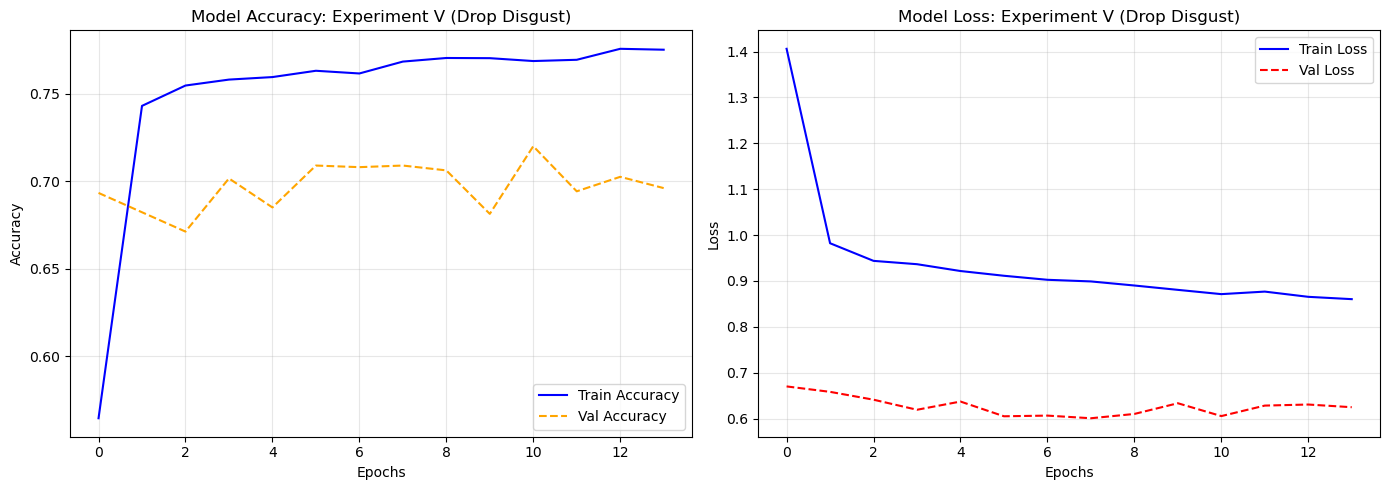

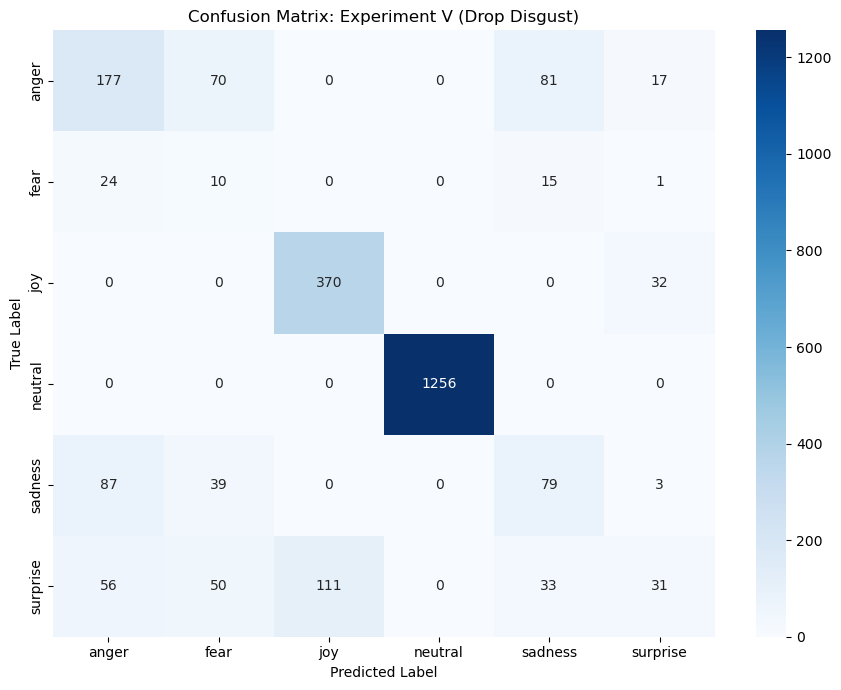

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from functions import prepare_datasets, slice_features, build_dynamic_model, Config

def run_experiment_V():
    EXP_NAME = "Experiment V (Drop Disgust)"
    
    print(f"\n{'='*60}\nRunning {EXP_NAME}\n{'='*60}")
    
    # 1. Prepare Data
    current_classes = ['neutral', 'joy', 'sadness', 'anger', 'surprise', 'fear']
    print(f"Target Classes: {current_classes}")
    
    # Load Data
    data = prepare_datasets(current_classes, augment=False)
    
    # 2. Features (Using All Features)
    feats = ['MFCC', 'Chroma', 'Spectral_Contrast', 'Zero_Crossing_Rate', 'RMS_Energy', 'Sentiment']
    inputs, shapes, types = slice_features(data, feats)
    
    # 3. Train Model
    tf.keras.backend.clear_session()
    gc.collect()
    
    model = build_dynamic_model(types, shapes, len(current_classes), data['num_sent_classes'])
    cw = class_weight.compute_class_weight('balanced', classes=np.unique(data['y_train']), y=data['y_train'])
    
    print("Training model...")
    history = model.fit(inputs['train'], data['y_train'], 
                        validation_data=(inputs['dev'], data['y_dev']), 
                        epochs=40, verbose=1, batch_size=32, 
                        class_weight=dict(enumerate(cw)),
                        callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
    
    # 4. Evaluate on Test Set
    print("Evaluating on Test Set...")
    y_pred_probs = model.predict(inputs['test'], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = data['y_test']
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    
    print(f"\n>>> Results for {EXP_NAME}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    
    print("\n>>> Classification Report")
    class_names = data['le_target'].classes_
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # ==========================================
    # 5. VISUALIZATION
    # ==========================================
    
    # --- A. Training Curves ---
    plt.figure(figsize=(14, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
    plt.title(f'Model Accuracy: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
    plt.title(f'Model Loss: {EXP_NAME}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- B. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title(f'Confusion Matrix: {EXP_NAME}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment_V()